In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD ENRICHED DATASET
# ============================================================

df2 = pd.read_csv("new_fraud_expanded_2.csv")

# ============================================================
# KEEP THE OLD PYTHON COLUMN NAMES
# ============================================================
# Original columns retain their old names so all existing
# analysis / graph code continues to work.
#
# New geographic/bank columns are added at the end.

df2["payment_format"] = df2["payment_mode"]
df2["amount_received"] = df2["amount_paid"]

# ============================================================
# PARSE TIMESTAMP
# ============================================================

df2["timestamp"] = pd.to_datetime(
    df2["timestamp"],
    # format="%Y/%m/%d %H:%M:%S",
    errors="coerce"
)

# ============================================================
# NUMERIC COLUMNS
# ============================================================

df2["amount_received"] = pd.to_numeric(
    df2["amount_received"],
    errors="coerce"
)

df2["amount_paid"] = pd.to_numeric(
    df2["amount_paid"],
    errors="coerce"
)

# ============================================================
# LAUNDERING FLAG
# ============================================================

df2["is_laundering"] = (
    df2["is_laundering"]
    .astype(str)
    .str.strip()
    .map({
        "1": True,
        "0": False,
        "True": True,
        "False": False
    })
)

# ============================================================
# CLEAN NEW LOCATION / BANK COLUMNS
# ============================================================

for col in [
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank"
]:
    df2[col] = (
        df2[col]
        .astype(str)
        .str.strip()
        .replace("nan", np.nan)
    )

# ============================================================
# BASIC INFORMATION
# ============================================================

print("Dataset shape:", df2.shape)

print("\nColumns:")
print(df2.columns.tolist())

print("\nMissing values:")
display(df2.isna().sum().to_frame("Missing"))

print("\nDataset preview:")
display(df2.head())

In [ ]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Total transactions : {len(df2):,}")
print(f"Total columns      : {len(df2.columns)}")

print("\nDate range:")
print(df2["timestamp"].min(), "→", df2["timestamp"].max())

print("\nUnique values:")
print(f"From banks        : {df2['from_indian_bank'].nunique():,}")
print(f"To banks          : {df2['to_indian_bank'].nunique():,}")
print(f"From accounts     : {df2['from_account'].nunique():,}")
print(f"To accounts       : {df2['to_account'].nunique():,}")
print(f"Payment formats   : {df2['payment_format'].nunique():,}")
print(f"Receiving currency: {df2['receiving_currency'].nunique():,}")
print(f"Payment currencies: {df2['payment_currency'].nunique():,}")

In [10]:
print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

print("\nMissing values:")
display(
    df2.isnull()
       .sum()
       .sort_values(ascending=False)
       .to_frame("missing_count")
)

print("\nDuplicate rows:")
print(df2.duplicated().sum())

print("\nDuplicate transaction-like records:")
print(
    df2.duplicated(
        subset=[
            "timestamp",
            "from_indian_bank",
            "from_account",
            "to_indian_bank",
            "to_account",
            "amount_paid"
        ]
    ).sum()
)

print("\nInvalid timestamps:")
print(df2["timestamp"].isna().sum())

print("\nInvalid amounts:")
print(
    ((df2["amount_paid"] < 0) |
     (df2["amount_paid"] < 0)).sum()
)

DATA QUALITY CHECK

Missing values:


,missing_count
target_account_original_frequency,4853
target_selection_score,4853
synthetic_delay_minutes,4853
target_account_profile_frequency,4853
target_district_distance_km,4853
second_stage_generation,4853
synthetic_source_tx2,4129
synthetic_bank_match,3565
synthetic_similarity_score,3565
synthetic_source_tx1,3565



Duplicate rows:
0

Duplicate transaction-like records:
0

Invalid timestamps:
0

Invalid amounts:
0


In [11]:
total = len(df2)

laundering = df2["is_laundering"].sum()
non_laundering = total - laundering

print("=" * 60)
print("LAUNDERING SUMMARY")
print("=" * 60)

print(f"Total transactions       : {total:,}")
print(f"Laundering transactions  : {laundering:,}")
print(f"Non-laundering           : {non_laundering:,}")

print(
    f"Laundering ratio         : "
    f"{laundering / total:.4%}"
)

print(
    f"Non-laundering ratio     : "
    f"{non_laundering / total:.4%}"
)

print("=" * 60)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 60)

display(
    df2.groupby("is_laundering")[
        ["amount_received", "amount_paid"]
    ].describe()
)

amount_summary = (
    df2.groupby("is_laundering")
       .agg(
           transaction_count=("timestamp", "count"),
           total_received=("amount_received", "sum"),
           average_received=("amount_received", "mean"),
           median_received=("amount_received", "median"),
           max_received=("amount_received", "max"),
           total_paid=("amount_paid", "sum"),
           average_paid=("amount_paid", "mean")
       )
)

display(amount_summary)

format_summary = (
    df2.groupby("payment_format")
       .agg(
           total_transactions=("timestamp", "count"),
           laundering_transactions=("is_laundering", "sum"),
           total_amount=("amount_received", "sum")
       )
)

format_summary["laundering_rate"] = (
    format_summary["laundering_transactions"] /
    format_summary["total_transactions"]
)

format_summary = format_summary.sort_values(
    "laundering_rate",
    ascending=False
)

display(format_summary)



LAUNDERING SUMMARY
Total transactions       : 5,417
Laundering transactions  : 5,417
Non-laundering           : 0
Laundering ratio         : 100.0000%
Non-laundering ratio     : 0.0000%
TRANSACTION AMOUNT ANALYSIS


amount_received                                        \
                        count          mean           std       min   
is_laundering                                                         
True                   5417.0  3.246261e+06  6.468448e+07  0.001136   

                                                           amount_paid  \
                       25%      50%      75%           max       count   
is_laundering                                                            
True           1574.508652  4371.67  13437.4  2.857290e+09      5417.0   

                                                                           \
                       mean           std       min          25%      50%   
is_laundering                                                               
True           3.246261e+06  6.468448e+07  0.001136  1574.508652  4371.67   

                                      
                   75%           max  
is_laundering                         
True           13437.4  2.857290e+09

,transaction_count,total_received,average_received,median_received,max_received,total_paid,average_paid
is_laundering,,,,,,,
True,5417,1.758500e+10,3.246261e+06,4371.67,2.857290e+09,1.758500e+10,3.246261e+06


,total_transactions,laundering_transactions,total_amount,laundering_rate
payment_format,,,,
ATM WITHDRAWAL,127,127,2.785939e+08,1.0
IMPS,4296,4296,1.519742e+10,1.0
OTHER DIGITAL,240,240,1.801883e+04,1.0
UPI,754,754,2.108961e+09,1.0


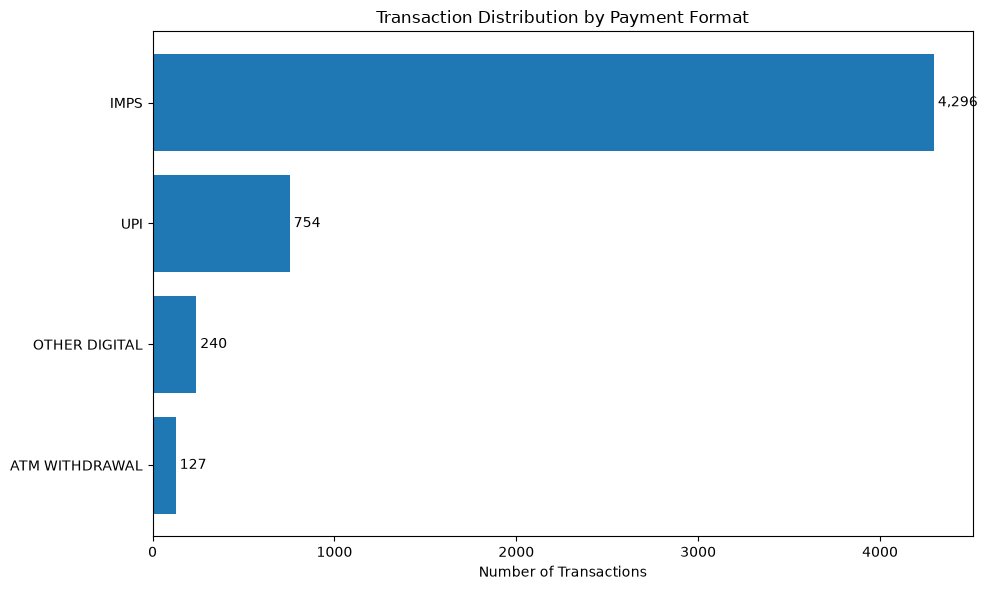

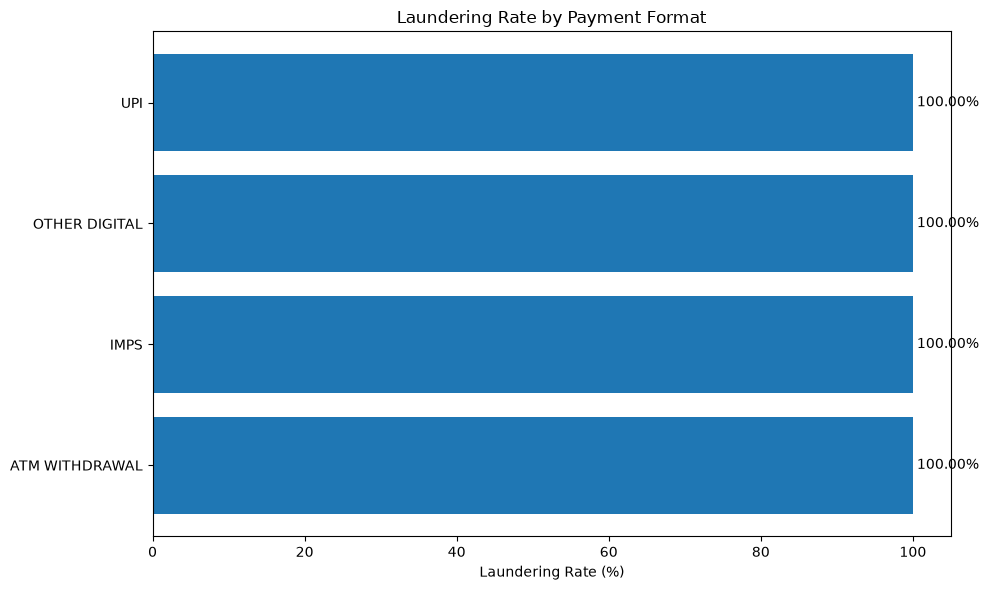

KeyError: 'legitimate'

In [12]:
format_counts = (
    df2["payment_format"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    format_counts.index,
    format_counts.values
)

plt.title("Transaction Distribution by Payment Format")
plt.xlabel("Number of Transactions")

for i, value in enumerate(format_counts.values):
    plt.text(
        value,
        i,
        f" {value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

format_rate = (
    df2.groupby("payment_format")["is_laundering"]
       .mean()
       .sort_values(ascending=True)
       * 100
)

plt.figure(figsize=(10, 6))

plt.barh(
    format_rate.index,
    format_rate.values
)

plt.title("Laundering Rate by Payment Format")
plt.xlabel("Laundering Rate (%)")

for i, value in enumerate(format_rate.values):
    plt.text(
        value,
        i,
        f" {value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

df2["day"] = df2["timestamp"].dt.day

daily_summary = (
    df2.groupby(["day", "is_laundering"])
       .size()
       .unstack(fill_value=0)
       .reindex(range(1, 32), fill_value=0)
)

daily_summary = daily_summary.rename(
    columns={
        False: "legitimate",
        True: "laundering"
    }
)

daily_summary["total"] = (
    daily_summary["legitimate"] +
    daily_summary["laundering"]
)

display(daily_summary)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_summary.index,
    daily_summary["legitimate"],
    marker="o",
    label="Non-laundering"
)

plt.plot(
    daily_summary.index,
    daily_summary["laundering"],
    marker="o",
    label="Laundering"
)

plt.title("Daily Transaction Distribution")
plt.xlabel("Day of Month")
plt.ylabel("Number of Transactions")

plt.xticks(range(1, 32))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

daily_format = (
    df2.groupby(["day", "payment_format"])
       .size()
       .unstack(fill_value=0)
       .reindex(range(1, 32), fill_value=0)
)

display(daily_format)

daily_format.plot(
    figsize=(14, 7),
    marker="o"
)

plt.title("Daily Transactions by Payment Format")
plt.xlabel("Day of Month")
plt.ylabel("Number of Transactions")
plt.xticks(range(1, 32))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [13]:
df2["hour"] = df2["timestamp"].dt.hour

hourly = (
    df2.groupby(["hour", "is_laundering"])
       .size()
       .unstack(fill_value=0)
       .reindex(range(24), fill_value=0)
)

hourly = hourly.rename(
    columns={
        False: "legitimate",
        True: "laundering"
    }
)

hourly["total"] = (
    hourly["legitimate"] +
    hourly["laundering"]
)

display(hourly)

hourly_rate = (
    df2.groupby("hour")["is_laundering"]
       .mean()
       * 100
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_rate.index,
    hourly_rate.values,
    marker="o"
)

plt.title("Laundering Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Laundering Rate (%)")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
bank_summary = (
    df2.groupby("from_indian_bank")
       .agg(
           transactions=("timestamp", "count"),
           laundering_transactions=("is_laundering", "sum"),
           total_amount=("amount_received", "sum")
       )
)

bank_summary["laundering_rate"] = (
    bank_summary["laundering_transactions"] /
    bank_summary["transactions"]
)

bank_summary = bank_summary.sort_values(
    "laundering_transactions",
    ascending=False
)

display(bank_summary.head(30))

account_summary = (
    df2.groupby("from_account")
       .agg(
           transactions=("timestamp", "count"),
           laundering_transactions=("is_laundering", "sum"),
           total_amount=("amount_received", "sum"),
           average_amount=("amount_received", "mean")
       )
)

account_summary["laundering_rate"] = (
    account_summary["laundering_transactions"] /
    account_summary["transactions"]
)

display(
    account_summary
    .sort_values("laundering_transactions", ascending=False)
    .head(30)
)

from_accounts = set(df2["from_account"].dropna())
to_accounts = set(df2["to_account"].dropna())

both = from_accounts.intersection(to_accounts)

print(f"Unique sender accounts   : {len(from_accounts):,}")
print(f"Unique receiver accounts : {len(to_accounts):,}")
print(f"Accounts appearing on BOTH sides: {len(both):,}")


laundering_df = df2[
    df2["is_laundering"] == True
]

laundering_from = set(
    laundering_df["from_account"].dropna()
)

laundering_to = set(
    laundering_df["to_account"].dropna()
)

laundering_both = laundering_from.intersection(
    laundering_to
)

print(
    "Laundering accounts appearing "
    f"as both sender and receiver: {len(laundering_both):,}"
)

KeyError: 'legitimate'

In [ ]:
%pip install networkx

In [ ]:
# import networkx as nx

# # Create directed transaction graph
# G = nx.DiGraph()

# for _, row in df2.iterrows():

#     src = row["from_account"]
#     dst = row["to_account"]

#     if pd.isna(src) or pd.isna(dst):
#         continue

#     # Add/update edge
#     if G.has_edge(src, dst):
#         G[src][dst]["transaction_count"] += 1
#         G[src][dst]["total_amount"] += row["amount_received"]

#         if row["is_laundering"]:
#             G[src][dst]["laundering_count"] += 1
#     else:
#         G.add_edge(
#             src,
#             dst,
#             transaction_count=1,
#             total_amount=row["amount_received"],
#             laundering_count=int(row["is_laundering"])
#         )

# print("Graph created")

# print(f"Nodes  : {G.number_of_nodes():,}")
# print(f"Edges  : {G.number_of_edges():,}")

In [ ]:
# print("=" * 60)
# print("TRANSACTION GRAPH STATISTICS")
# print("=" * 60)

# print(f"Number of accounts : {G.number_of_nodes():,}")
# print(f"Number of connections : {G.number_of_edges():,}")

# print(f"Average degree : {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

# # Accounts involved in laundering transactions
# laundering_rows = df2[df2["is_laundering"] == True]

# laundering_accounts = set(
#     laundering_rows["from_account"]
# ).union(
#     set(laundering_rows["to_account"])
# )

# print(f"Laundering-involved accounts : {len(laundering_accounts):,}")

# print(f"Graph density : {nx.density(G):.6f}")

# print("=" * 60)
# print("TRANSACTION GRAPH STATISTICS")
# print("=" * 60)

# print(f"Number of accounts : {G.number_of_nodes():,}")
# print(f"Number of connections : {G.number_of_edges():,}")

# print(f"Average degree : {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

# # Accounts involved in laundering transactions
# laundering_rows = df2[df2["is_laundering"] == True]

# laundering_accounts = set(
#     laundering_rows["from_account"]
# ).union(
#     set(laundering_rows["to_account"])
# )

# print(f"Laundering-involved accounts : {len(laundering_accounts):,}")

# print(f"Graph density : {nx.density(G):.6f}")

# degree_df = pd.DataFrame({
#     "account": list(G.nodes()),
#     "degree": [G.degree(n) for n in G.nodes()],
#     "in_degree": [G.in_degree(n) for n in G.nodes()],
#     "out_degree": [G.out_degree(n) for n in G.nodes()]
# })

# degree_df = degree_df.sort_values(
#     "degree",
#     ascending=False
# )

# display(degree_df.head(30))

In [ ]:
# # Keep laundering-related edges
# laundering_edges = []

# for u, v, data in G.edges(data=True):

#     if data["laundering_count"] > 0:
#         laundering_edges.append(
#             (u, v)
#         )

# G_laundering = G.edge_subgraph(
#     laundering_edges
# ).copy()

# print("Laundering subgraph:")
# print(f"Nodes : {G_laundering.number_of_nodes():,}")
# print(f"Edges : {G_laundering.number_of_edges():,}")

# plt.figure(figsize=(16, 12))

# # If graph is very large, visualize only the largest connected component
# if G_laundering.number_of_nodes() > 100:

#     components = sorted(
#         nx.weakly_connected_components(G_laundering),
#         key=len,
#         reverse=True
#     )

#     # Take largest component
#     nodes_to_plot = components[0]

#     G_plot = G_laundering.subgraph(
#         nodes_to_plot
#     ).copy()

#     print(
#         f"Graph too large — showing largest component "
#         f"with {len(G_plot.nodes()):,} accounts."
#     )

# else:
#     G_plot = G_laundering


# # Layout
# pos = nx.spring_layout(
#     G_plot,
#     seed=42,
#     k=1.5,
#     iterations=100
# )

# # Node size based on degree
# node_sizes = [
#     100 + G_plot.degree(n) * 80
#     for n in G_plot.nodes()
# ]

# # Draw nodes
# nx.draw_networkx_nodes(
#     G_plot,
#     pos,
#     node_size=node_sizes,
#     alpha=0.85
# )

# # Draw edges
# nx.draw_networkx_edges(
#     G_plot,
#     pos,
#     arrows=True,
#     arrowsize=12,
#     alpha=0.5,
#     width=1
# )

# # Labels
# nx.draw_networkx_labels(
#     G_plot,
#     pos,
#     font_size=7
# )

# plt.title(
#     "Suspicious Transaction Network",
#     fontsize=16
# )

# plt.axis("off")
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(16, 12))

# pos = nx.spring_layout(
#     G_plot,
#     seed=42,
#     k=1.5,
#     iterations=100
# )

# # Nodes involved in laundering
# laundering_nodes = set(
#     laundering_rows["from_account"]
# ).union(
#     laundering_rows["to_account"]
# )

# normal_nodes = [
#     n for n in G_plot.nodes()
#     if n not in laundering_nodes
# ]

# suspicious_nodes = [
#     n for n in G_plot.nodes()
#     if n in laundering_nodes
# ]

# # Normal nodes
# nx.draw_networkx_nodes(
#     G_plot,
#     pos,
#     nodelist=normal_nodes,
#     node_size=120,
#     alpha=0.5
# )

# # Suspicious nodes
# nx.draw_networkx_nodes(
#     G_plot,
#     pos,
#     nodelist=suspicious_nodes,
#     node_size=350,
#     node_color="red",
#     alpha=0.85
# )

# # Edges
# nx.draw_networkx_edges(
#     G_plot,
#     pos,
#     arrows=True,
#     arrowsize=12,
#     alpha=0.35
# )

# # Labels only for suspicious nodes
# nx.draw_networkx_labels(
#     G_plot,
#     pos,
#     labels={
#         n: n for n in suspicious_nodes
#     },
#     font_size=8
# )

# plt.title(
#     "Transaction Graph — Laundering Accounts Highlighted",
#     fontsize=16
# )

# plt.axis("off")
# plt.tight_layout()
# plt.show()

# # Find laundering-related paths of length 2–4

# paths = []

# for source in G_laundering.nodes():

#     for target in G_laundering.nodes():

#         if source == target:
#             continue

#         try:
#             for path in nx.all_simple_paths(
#                 G_laundering,
#                 source=source,
#                 target=target,
#                 cutoff=4
#             ):

#                 if len(path) >= 3:
#                     paths.append(path)

#                 if len(paths) >= 50:
#                     break

#         except nx.NetworkXNoPath:
#             pass

#         if len(paths) >= 50:
#             break

#     if len(paths) >= 50:
#         break


# print("Example transaction chains:\n")

# for path in paths[:20]:
#     print(" → ".join(path))

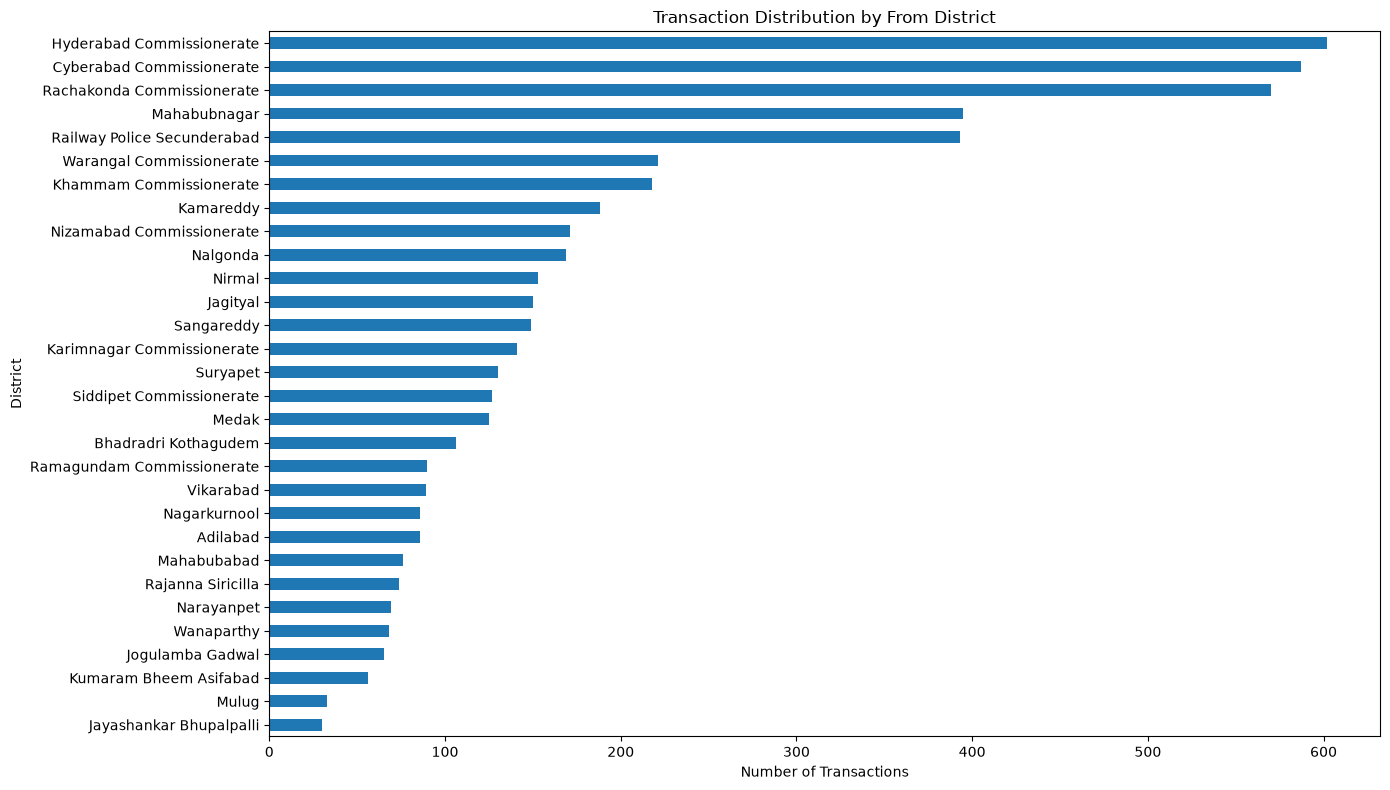

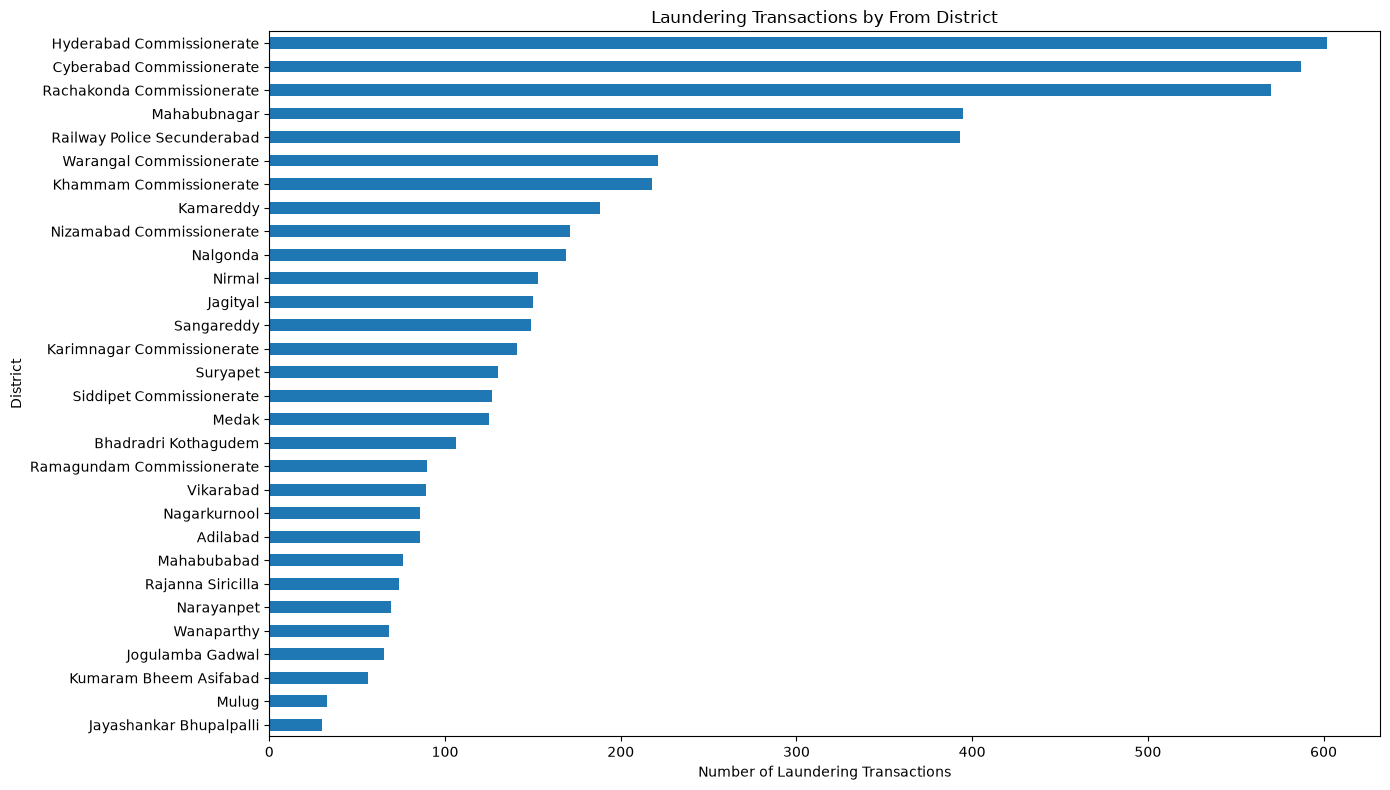

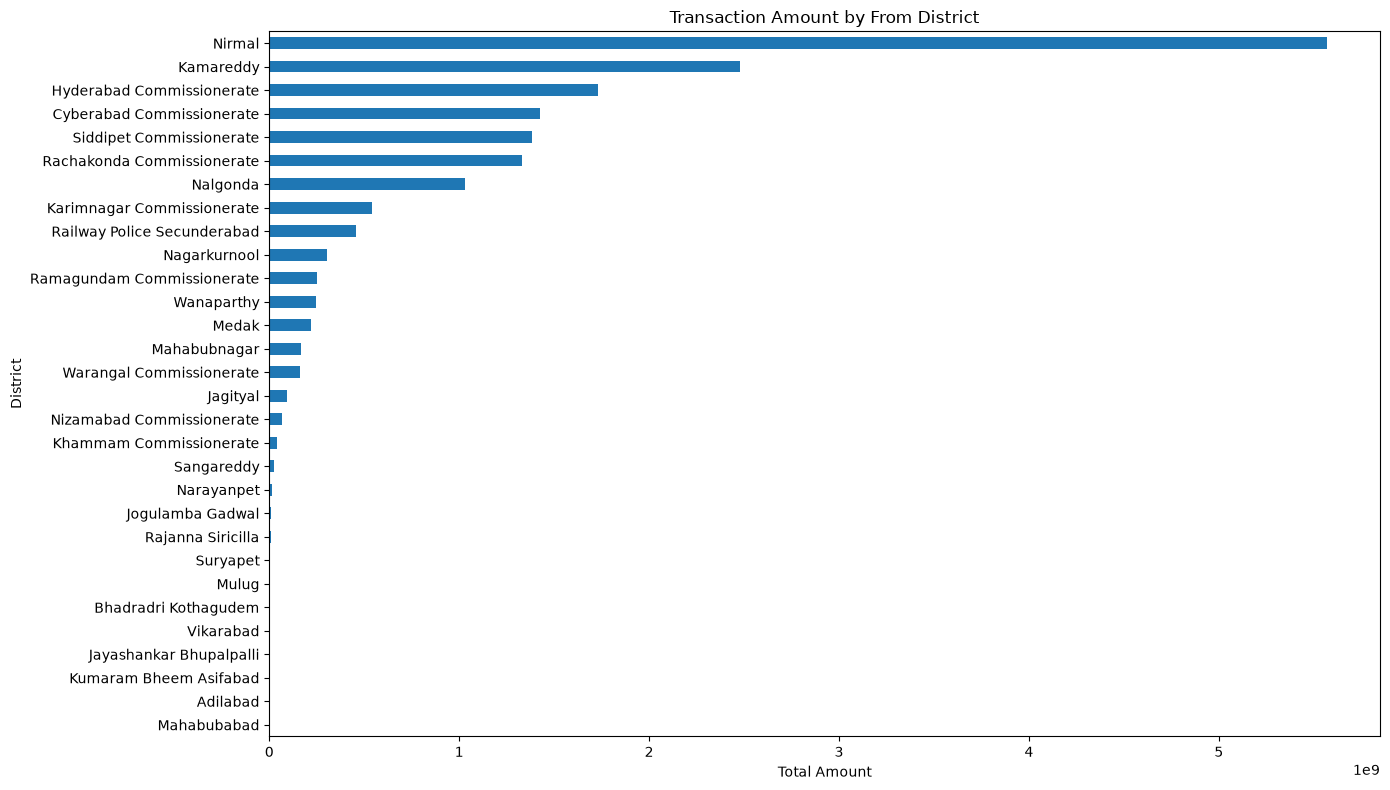

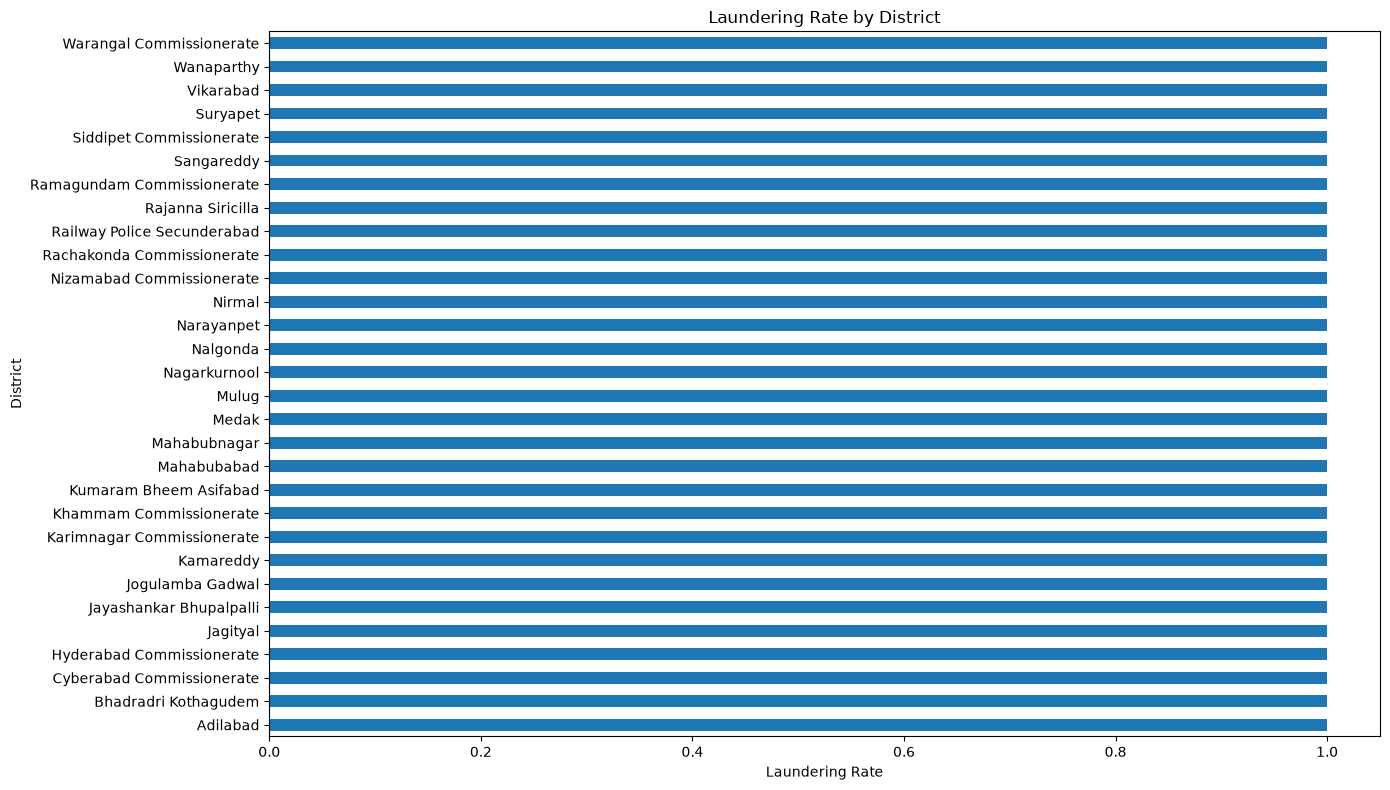

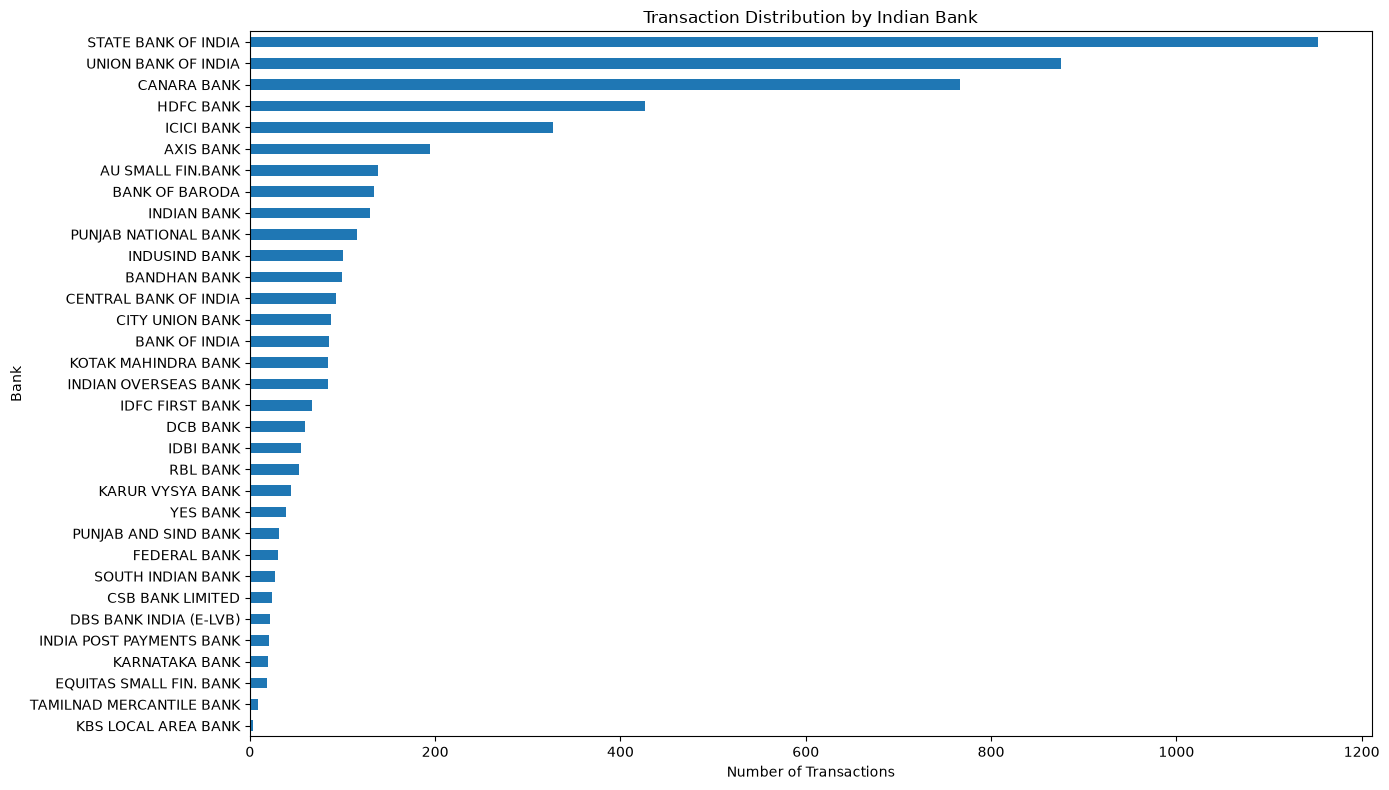

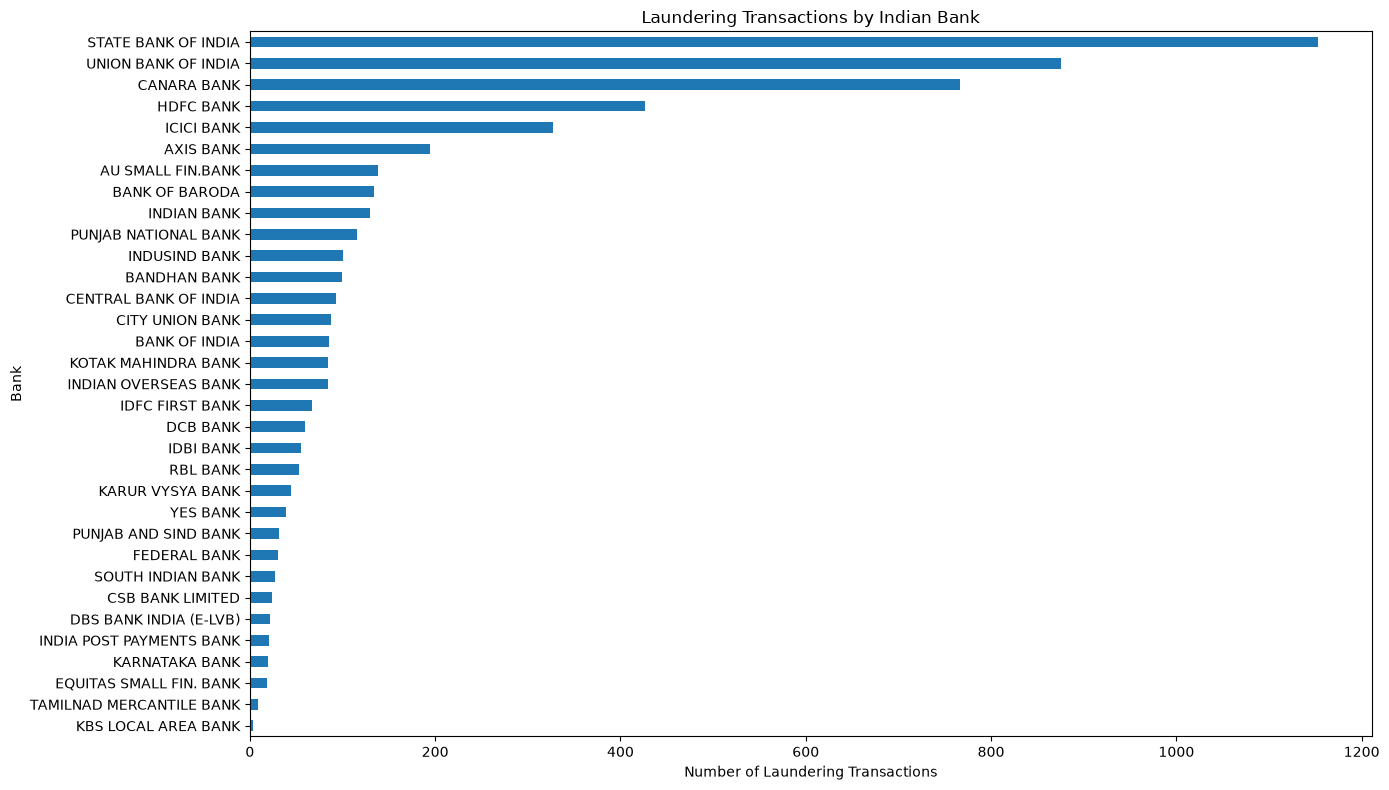

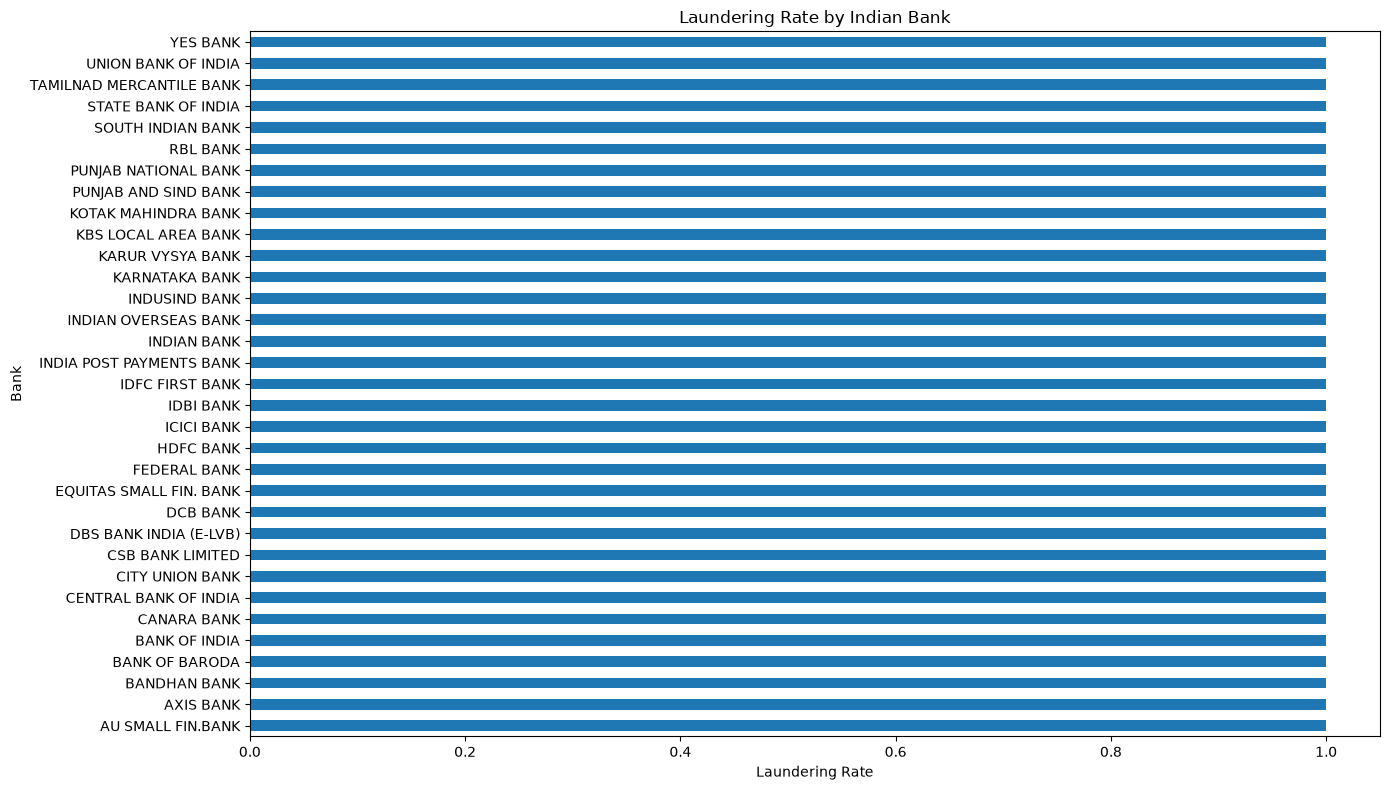

<Figure size 1600x1000 with 0 Axes>

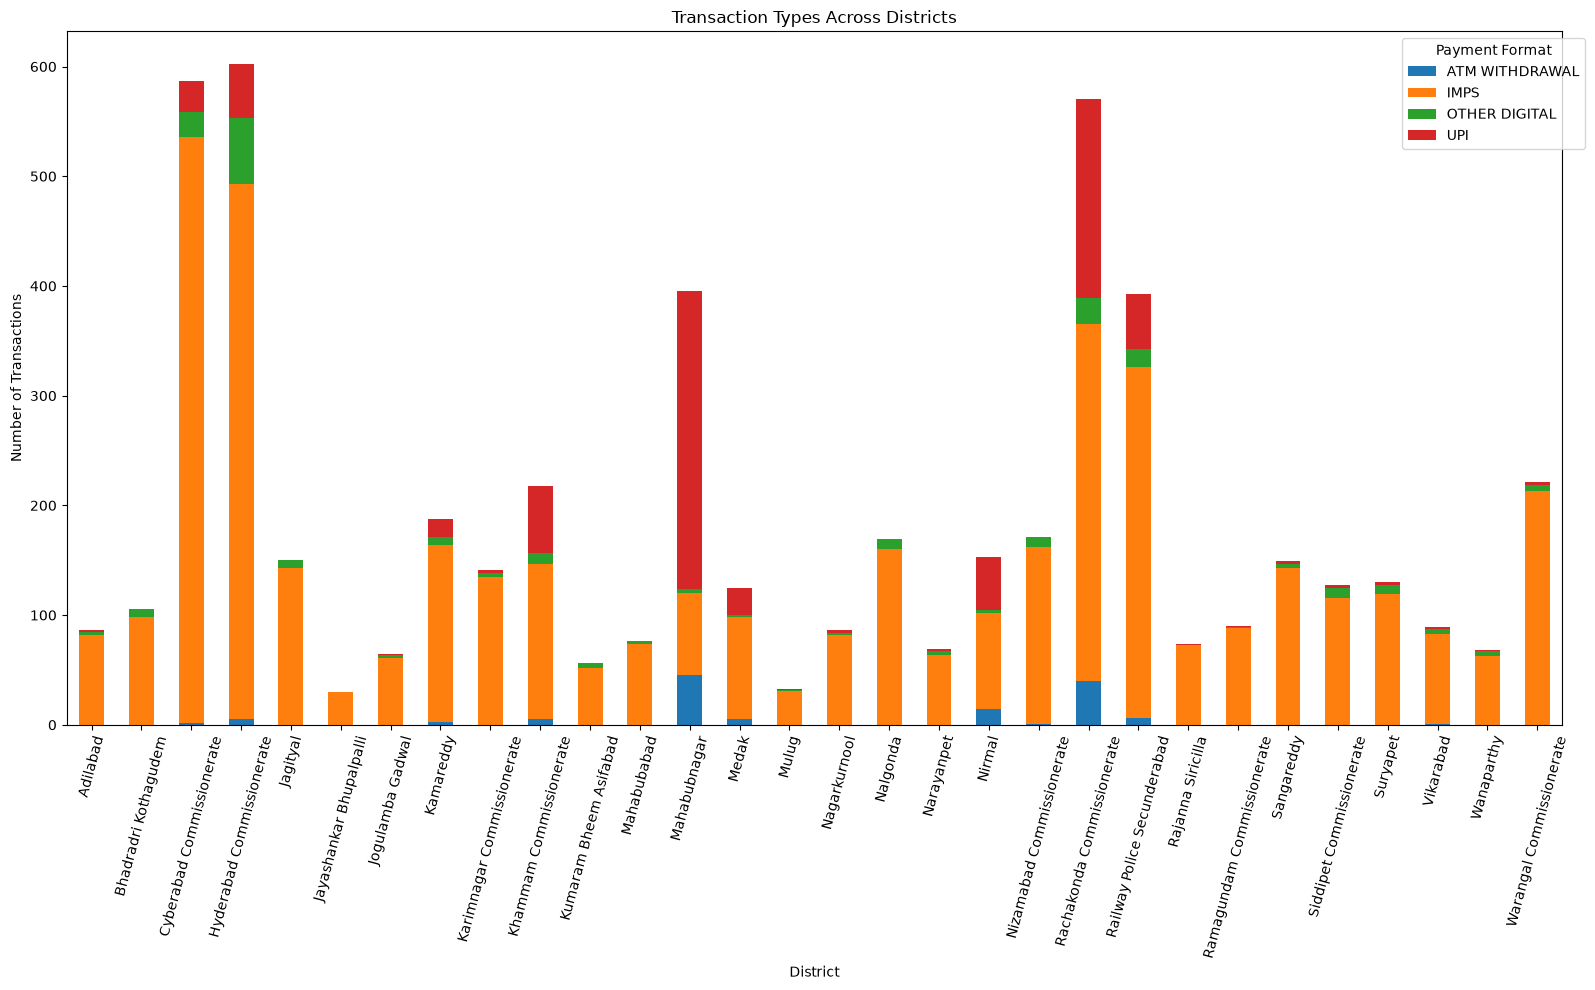

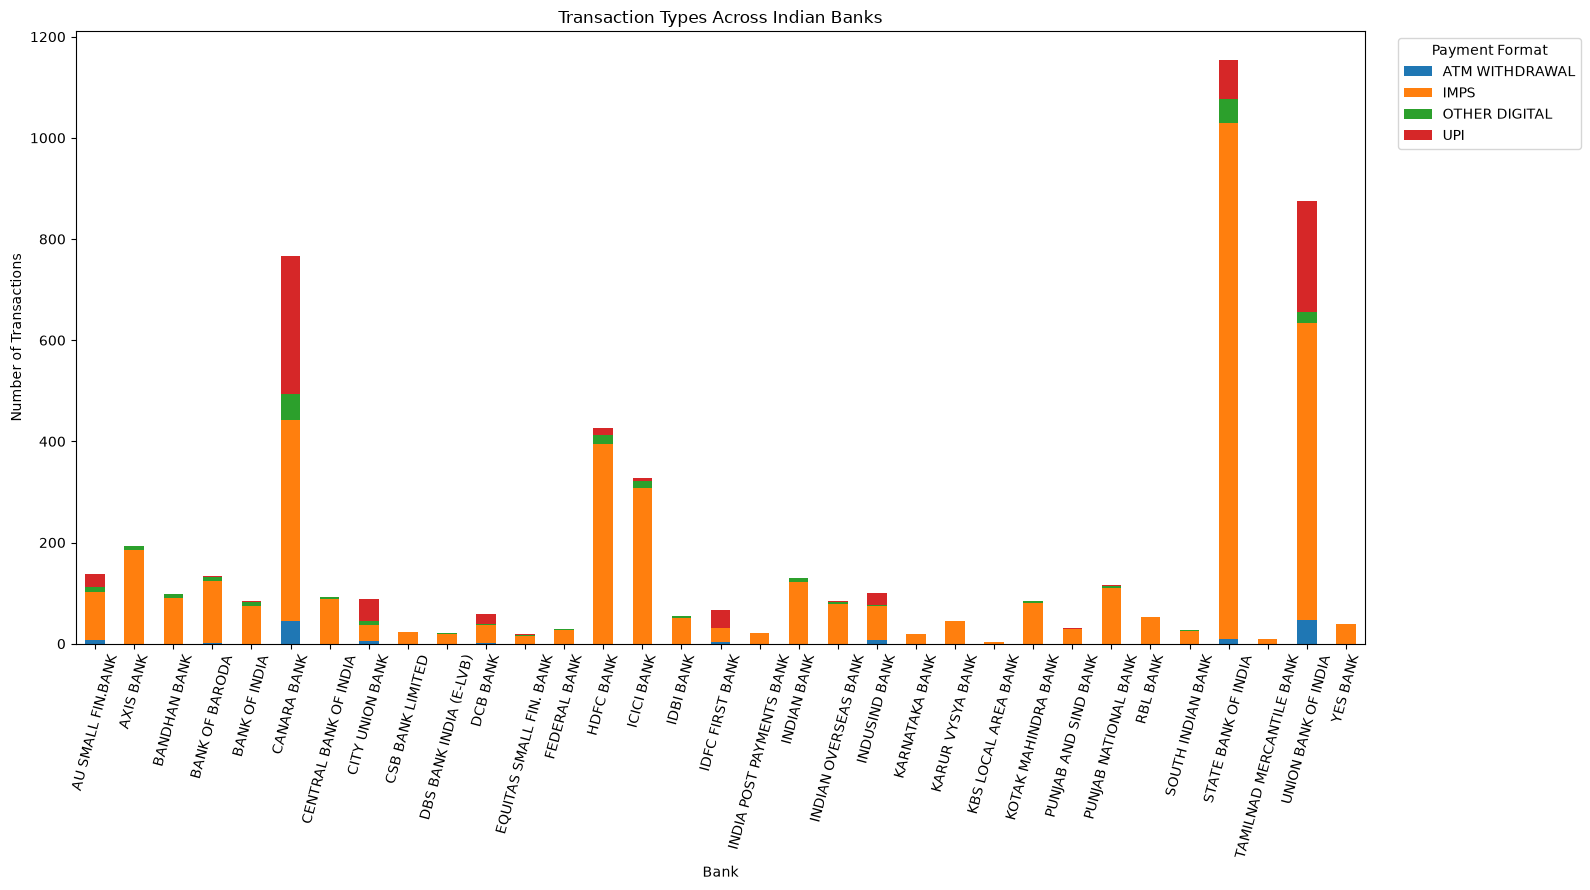

is_laundering,Laundering
from_district,
Hyderabad Commissionerate,602
Cyberabad Commissionerate,587
Rachakonda Commissionerate,570
Mahabubnagar,395
Railway Police Secunderabad,393
Warangal Commissionerate,221
Khammam Commissionerate,218
Kamareddy,188
Nizamabad Commissionerate,171


is_laundering,Laundering
from_indian_bank,
STATE BANK OF INDIA,1153
UNION BANK OF INDIA,875
CANARA BANK,767
HDFC BANK,427
ICICI BANK,327
AXIS BANK,194
AU SMALL FIN.BANK,138
BANK OF BARODA,134
INDIAN BANK,130


District-to-district transaction matrix:


to_district,Adilabad,Bhadradri Kothagudem,Cyberabad Commissionerate,Hyderabad Commissionerate,Jagityal,Jayashankar Bhupalpalli,Jogulamba Gadwal,Kamareddy,Karimnagar Commissionerate,Khammam Commissionerate,...,Railway Police Secunderabad,Rajanna Sircilla,Rajanna Siricilla,Ramagundam Commissionerate,Sangareddy,Siddipet Commissionerate,Suryapet,Vikarabad,Wanaparthy,Warangal Commissionerate
from_district,,,,,,,,,,,,,,,,,,,,,
Adilabad,18,0,12,10,2,1,0,5,6,3,...,8,0,1,1,1,4,0,0,1,2
Bhadradri Kothagudem,2,12,18,15,5,0,1,3,0,2,...,7,0,1,1,6,3,1,3,2,4
Cyberabad Commissionerate,19,14,42,55,10,3,8,24,14,18,...,50,0,8,11,23,15,27,22,9,24
Hyderabad Commissionerate,12,28,60,68,14,7,13,19,10,19,...,34,0,11,8,26,17,12,10,12,19
Jagityal,2,2,24,18,4,1,2,9,6,4,...,8,0,2,3,3,3,2,4,1,6
Jayashankar Bhupalpalli,0,2,2,7,1,0,1,2,0,2,...,5,0,0,1,0,0,1,2,0,1
Jogulamba Gadwal,1,1,6,7,2,0,13,0,0,1,...,8,0,0,3,1,0,3,1,0,1
Kamareddy,3,4,20,24,3,2,2,25,3,5,...,14,0,1,5,10,4,3,6,3,8
Karimnagar Commissionerate,4,6,9,19,3,0,4,7,3,4,...,14,1,3,3,2,1,4,6,2,4


Top 25 district-to-district flows:


...

,from_indian_bank,to_indian_bank,transactions
563,STATE BANK OF INDIA,STATE BANK OF INDIA,582
605,UNION BANK OF INDIA,UNION BANK OF INDIA,300
115,CANARA BANK,CANARA BANK,173
265,HDFC BANK,HDFC BANK,164
139,CANARA BANK,STATE BANK OF INDIA,162
603,UNION BANK OF INDIA,STATE BANK OF INDIA,153
294,ICICI BANK,ICICI BANK,134
565,STATE BANK OF INDIA,UNION BANK OF INDIA,86
280,HDFC BANK,STATE BANK OF INDIA,81
547,STATE BANK OF INDIA,HDFC BANK,77



DISTRICT SUMMARY


,transactions,total_amount,laundering_transactions,unique_accounts,unique_banks,laundering_rate
from_district,,,,,,
Hyderabad Commissionerate,602,1.732227e+09,602,483,30,1.0
Cyberabad Commissionerate,587,1.427166e+09,587,478,31,1.0
Rachakonda Commissionerate,570,1.330248e+09,570,293,33,1.0
Mahabubnagar,395,1.675965e+08,395,79,17,1.0
Railway Police Secunderabad,393,4.552144e+08,393,294,31,1.0
Warangal Commissionerate,221,1.614544e+08,221,197,30,1.0
Khammam Commissionerate,218,4.158848e+07,218,141,25,1.0
Kamareddy,188,2.479851e+09,188,128,26,1.0
Nizamabad Commissionerate,171,6.644009e+07,171,147,24,1.0



BANK SUMMARY


,transactions,total_amount,laundering_transactions,unique_accounts,unique_districts,laundering_rate
from_indian_bank,,,,,,
STATE BANK OF INDIA,1153,2.849675e+09,1153,969,30,1.0
UNION BANK OF INDIA,875,1.071183e+09,875,529,30,1.0
CANARA BANK,767,3.697209e+08,767,345,30,1.0
HDFC BANK,427,2.149397e+09,427,363,30,1.0
ICICI BANK,327,9.893685e+08,327,283,30,1.0
AXIS BANK,194,4.644194e+07,194,174,26,1.0
AU SMALL FIN.BANK,138,5.880571e+08,138,81,27,1.0
BANK OF BARODA,134,2.863958e+09,134,127,27,1.0
INDIAN BANK,130,2.255845e+09,130,112,28,1.0


In [14]:
# ============================================================
# TRANSACTION-LEVEL DISTRICT & BANK ANALYSIS
# Uses existing df2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. DISTRICT DISTRIBUTION — TRANSACTION COUNT
# ------------------------------------------------------------

from_district_counts = (
    df2["from_district"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
from_district_counts.sort_values().plot(kind="barh")
plt.title("Transaction Distribution by From District")
plt.xlabel("Number of Transactions")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. DISTRICT DISTRIBUTION — LAUNDERING TRANSACTIONS
# ------------------------------------------------------------

district_laundering = (
    df2[df2["is_laundering"]]
    ["from_district"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
district_laundering.sort_values().plot(kind="barh")
plt.title("Laundering Transactions by From District")
plt.xlabel("Number of Laundering Transactions")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. DISTRICT — TOTAL AMOUNT
# ------------------------------------------------------------

district_amount = (
    df2.groupby("from_district")["amount_received"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
district_amount.sort_values().plot(kind="barh")
plt.title("Transaction Amount by From District")
plt.xlabel("Total Amount")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. DISTRICT — LAUNDERING RATE
# ------------------------------------------------------------

district_stats = (
    df2.groupby("from_district")
    .agg(
        transactions=("from_district", "size"),
        laundering_transactions=("is_laundering", "sum"),
        total_amount=("amount_received", "sum"),
        laundering_amount=(
            "amount_received",
            lambda x: x[df2.loc[x.index, "is_laundering"]].sum()
        )
    )
)

district_stats["laundering_rate"] = (
    district_stats["laundering_transactions"]
    / district_stats["transactions"]
)

district_stats = district_stats.sort_values(
    "laundering_rate",
    ascending=False
)

plt.figure(figsize=(14, 8))
district_stats["laundering_rate"].sort_values().plot(
    kind="barh"
)
plt.title("Laundering Rate by District")
plt.xlabel("Laundering Rate")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. BANK DISTRIBUTION — TRANSACTION COUNT
# ------------------------------------------------------------

bank_counts = (
    df2["from_indian_bank"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
bank_counts.sort_values().plot(kind="barh")
plt.title("Transaction Distribution by Indian Bank")
plt.xlabel("Number of Transactions")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. BANK — LAUNDERING TRANSACTIONS
# ------------------------------------------------------------

bank_laundering = (
    df2[df2["is_laundering"]]
    ["from_indian_bank"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
bank_laundering.sort_values().plot(kind="barh")
plt.title("Laundering Transactions by Indian Bank")
plt.xlabel("Number of Laundering Transactions")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. BANK — LAUNDERING RATE
# ------------------------------------------------------------

bank_stats = (
    df2.groupby("from_indian_bank")
    .agg(
        transactions=("from_indian_bank", "size"),
        laundering_transactions=("is_laundering", "sum"),
        total_amount=("amount_received", "sum")
    )
)

bank_stats["laundering_rate"] = (
    bank_stats["laundering_transactions"]
    / bank_stats["transactions"]
)

bank_stats = bank_stats.sort_values(
    "laundering_rate",
    ascending=False
)

plt.figure(figsize=(14, 8))
bank_stats["laundering_rate"].sort_values().plot(
    kind="barh"
)
plt.title("Laundering Rate by Indian Bank")
plt.xlabel("Laundering Rate")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. PAYMENT FORMAT × DISTRICT
# ------------------------------------------------------------

district_payment = pd.crosstab(
    df2["from_district"],
    df2["payment_format"]
)

plt.figure(figsize=(16, 10))
district_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 10)
)
plt.title("Transaction Types Across Districts")
plt.xlabel("District")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=75)
plt.legend(title="Payment Format", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. PAYMENT FORMAT × BANK
# ------------------------------------------------------------

bank_payment = pd.crosstab(
    df2["from_indian_bank"],
    df2["payment_format"]
)

bank_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 9)
)

plt.title("Transaction Types Across Indian Banks")
plt.xlabel("Bank")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=75)
plt.legend(
    title="Payment Format",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. DISTRICT × LAUNDERING STATUS
# ------------------------------------------------------------

district_laundering_table = pd.crosstab(
    df2["from_district"],
    df2["is_laundering"]
)

district_laundering_table = district_laundering_table.rename(
    columns={
        False: "Legitimate",
        True: "Laundering"
    }
)

display(
    district_laundering_table
    .sort_values("Laundering", ascending=False)
)


# ------------------------------------------------------------
# 11. BANK × LAUNDERING STATUS
# ------------------------------------------------------------

bank_laundering_table = pd.crosstab(
    df2["from_indian_bank"],
    df2["is_laundering"]
)

bank_laundering_table = bank_laundering_table.rename(
    columns={
        False: "Legitimate",
        True: "Laundering"
    }
)

display(
    bank_laundering_table
    .sort_values("Laundering", ascending=False)
)


# ------------------------------------------------------------
# 12. DISTRICT → DISTRICT TRANSACTION FLOW
# ------------------------------------------------------------

district_flow = pd.crosstab(
    df2["from_district"],
    df2["to_district"]
)

print("District-to-district transaction matrix:")
display(district_flow)


# ------------------------------------------------------------
# 13. TOP DISTRICT FLOWS
# ------------------------------------------------------------

top_district_flows = (
    df2.groupby(
        ["from_district", "to_district"]
    )
    .size()
    .reset_index(name="transactions")
    .sort_values(
        "transactions",
        ascending=False
    )
    .head(25)
)

print("Top 25 district-to-district flows:")
display(top_district_flows)


# ------------------------------------------------------------
# 14. TOP BANK FLOWS
# ------------------------------------------------------------

top_bank_flows = (
    df2.groupby(
        ["from_indian_bank", "to_indian_bank"]
    )
    .size()
    .reset_index(name="transactions")
    .sort_values(
        "transactions",
        ascending=False
    )
    .head(25)
)

print("Top 25 bank-to-bank flows:")
display(top_bank_flows)


# ------------------------------------------------------------
# 15. SUMMARY TABLE — DISTRICTS
# ------------------------------------------------------------

print("\nDISTRICT SUMMARY")

district_summary = (
    df2.groupby("from_district")
    .agg(
        transactions=("from_district", "size"),
        total_amount=("amount_received", "sum"),
        laundering_transactions=("is_laundering", "sum"),
        unique_accounts=("from_account", "nunique"),
        unique_banks=("from_indian_bank", "nunique")
    )
)

district_summary["laundering_rate"] = (
    district_summary["laundering_transactions"]
    / district_summary["transactions"]
)

display(
    district_summary
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
)


# ------------------------------------------------------------
# 16. SUMMARY TABLE — BANKS
# ------------------------------------------------------------

print("\nBANK SUMMARY")

bank_summary = (
    df2.groupby("from_indian_bank")
    .agg(
        transactions=("from_indian_bank", "size"),
        total_amount=("amount_received", "sum"),
        laundering_transactions=("is_laundering", "sum"),
        unique_accounts=("from_account", "nunique"),
        unique_districts=("from_district", "nunique")
    )
)

bank_summary["laundering_rate"] = (
    bank_summary["laundering_transactions"]
    / bank_summary["transactions"]
)

display(
    bank_summary
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
)

ENRICHED ACCOUNTS DATASET

Dataset shape: (712688, 18)

Columns:
['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name', 'District', 'Indian Bank', 'total_transactions', 'total_amount', 'laundering_transactions', 'laundering_rate', 'Population', 'Crime Count', 'Population Share', 'Crime Share', 'Crime_Population_Index', 'Branch Weight', 'Bank Share']

Preview:


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name,District,Indian Bank,total_transactions,total_amount,laundering_transactions,laundering_rate,Population,Crime Count,Population Share,Crime Share,Crime_Population_Index,Branch Weight,Bank Share
0,China Bank #2820,314693,81B86A280,800D8CCF0,Corporation #41344,Sangareddy,STATE BANK OF INDIA,2.0,2547.58,0.0,0.0,1527628.0,286.0,0.041484,0.018696,0.450697,1215.0,0.231870
1,France Bank #4585,311253,8187FEA80,800B505E0,Corporation #54497,Jagityal,UNION BANK OF INDIA,2.0,5388.60,0.0,0.0,985417.0,156.0,0.026759,0.010198,0.381101,683.0,0.130344
2,China Bank #2242,39996,803961E00,800D03F60,Partnership #36904,Railway Police Secunderabad,UNION BANK OF INDIA,2.0,2341.64,0.0,0.0,3943323.0,0.0,0.107083,0.000000,0.000000,683.0,0.130344
3,National Bank of Newport,331440,81B075800,801567C10,Corporation #16224,Vikarabad,CANARA BANK,2.0,1563.60,0.0,0.0,927140.0,41.0,0.025177,0.002680,0.106457,396.0,0.075573
4,UK Bank #33,135417,80CF87C80,801085E00,Partnership #72930,Narayanpet,KARUR VYSYA BANK,9.0,113375.21,0.0,0.0,566874.0,49.0,0.015394,0.003203,0.208087,65.0,0.012405



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Bank Name,712688,27652,First Bank of Danbury,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bank ID,712688.0,NaN,NaN,NaN,124162.203066,125918.383483,0.0,15680.0,57466.0,231905.0,376967.0
Account Number,712688,712684,817037B20,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Entity ID,712688,224931,8015B10D0,8899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Entity Name,712688,224931,Partnership #953,8899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,705907,30,Hyderabad Commissionerate,75592,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Indian Bank,705907,33,STATE BANK OF INDIA,163193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_transactions,705907.0,NaN,NaN,NaN,19.617605,328.238136,1.0,2.0,6.0,27.0,223590.0
total_amount,705907.0,NaN,NaN,NaN,107897025.982167,11961749700.46261,0.000001,2918.74,39789.52,607992.44,7324817268628.630859
laundering_transactions,705907.0,NaN,NaN,NaN,0.0101,0.477825,0.0,0.0,0.0,0.0,314.0



Missing values:


,Missing
total_amount,6781
District,6781
Crime Share,6781
Crime_Population_Index,6781
total_transactions,6781
Indian Bank,6781
laundering_transactions,6781
Crime Count,6781
Population,6781
laundering_rate,6781


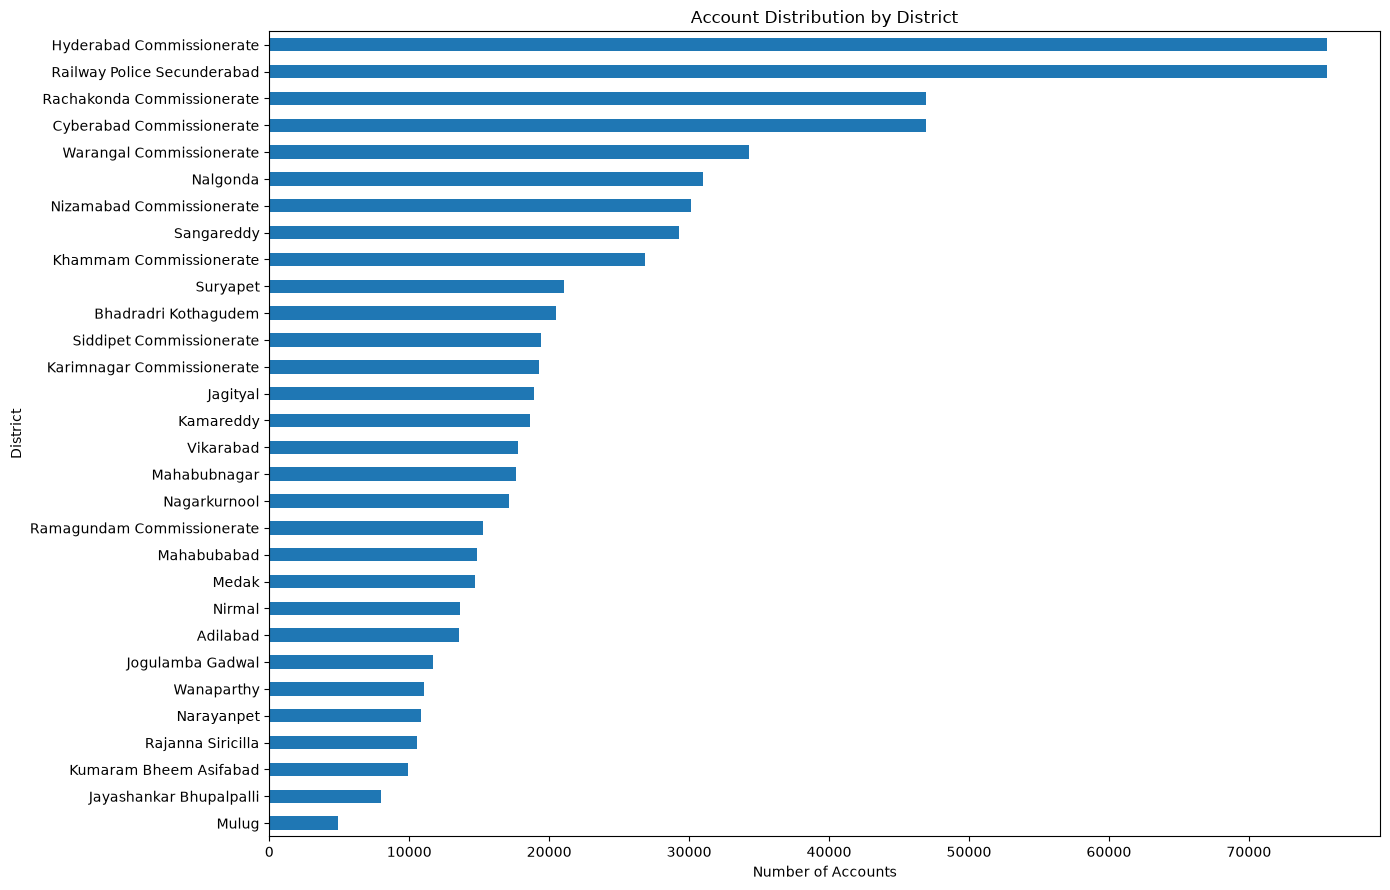

,accounts,population,crime_count,population_share,crime_share,total_transactions,laundering_transactions,actual_account_share,laundering_rate,account_share_error
District,,,,,,,,,,
Hyderabad Commissionerate,75592,3943323.0,4436.0,0.107083,0.289992,1468905.0,809.0,0.107085,0.000551,1.992011e-06
Railway Police Secunderabad,75591,3943323.0,0.0,0.107083,0.000000,1452810.0,541.0,0.107084,0.000372,5.753938e-07
Rachakonda Commissionerate,46894,2446265.0,2192.0,0.066430,0.143296,1034447.0,712.0,0.066431,0.000688,1.280620e-06
Cyberabad Commissionerate,46893,2446265.0,5424.0,0.066430,0.354579,902354.0,792.0,0.066429,0.000878,-1.359976e-07
Warangal Commissionerate,34301,1789395.0,631.0,0.048592,0.041250,646600.0,306.0,0.048591,0.000473,-5.418900e-07
Nalgonda,31024,1618416.0,95.0,0.043949,0.006210,582046.0,221.0,0.043949,0.000380,2.249788e-07
Nizamabad Commissionerate,30115,1571022.0,134.0,0.042662,0.008760,568790.0,223.0,0.042661,0.000392,-4.719568e-07
Sangareddy,29283,1527628.0,286.0,0.041484,0.018696,544503.0,233.0,0.041483,0.000428,-7.113959e-07
Khammam Commissionerate,26868,1401639.0,237.0,0.038062,0.015493,541461.0,284.0,0.038062,0.000525,-5.467612e-07


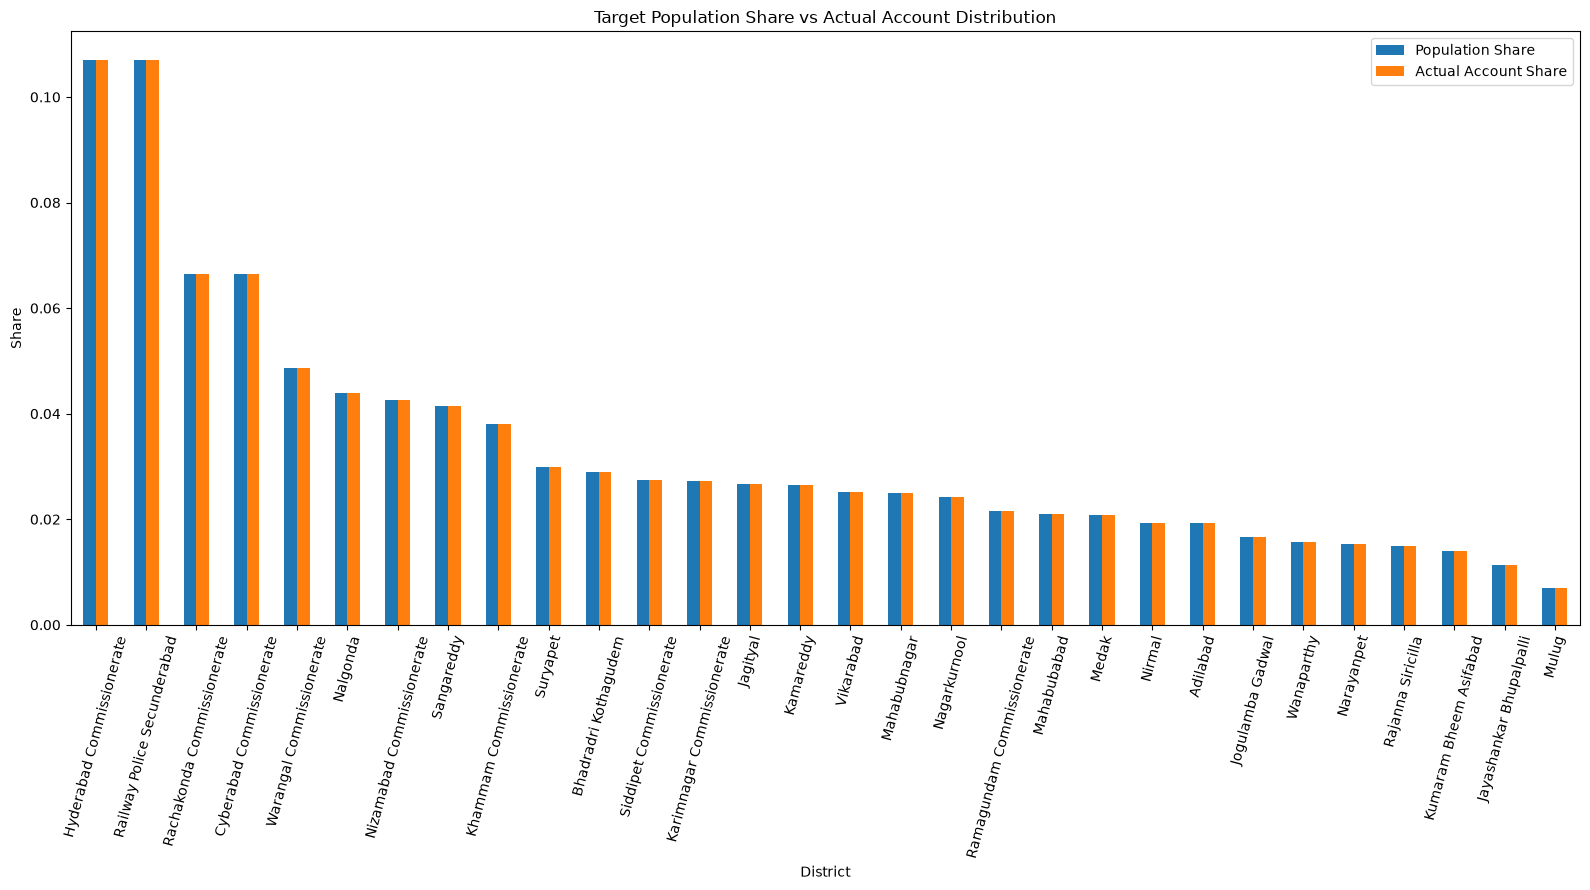

,accounts,laundering_accounts,laundering_transactions,total_transactions,accounts_with_laundering_rate,transaction_laundering_rate
District,,,,,,
Hyderabad Commissionerate,75592,650,809.0,1468905.0,0.008599,0.000551
Cyberabad Commissionerate,46893,619,792.0,902354.0,0.013200,0.000878
Rachakonda Commissionerate,46894,391,712.0,1034447.0,0.008338,0.000688
Railway Police Secunderabad,75591,417,541.0,1452810.0,0.005517,0.000372
Mahabubnagar,17634,108,443.0,557998.0,0.006125,0.000794
Warangal Commissionerate,34301,269,306.0,646600.0,0.007842,0.000473
Khammam Commissionerate,26868,198,284.0,541461.0,0.007369,0.000525
Kamareddy,18644,169,255.0,374600.0,0.009065,0.000681
Sangareddy,29283,195,233.0,544503.0,0.006659,0.000428


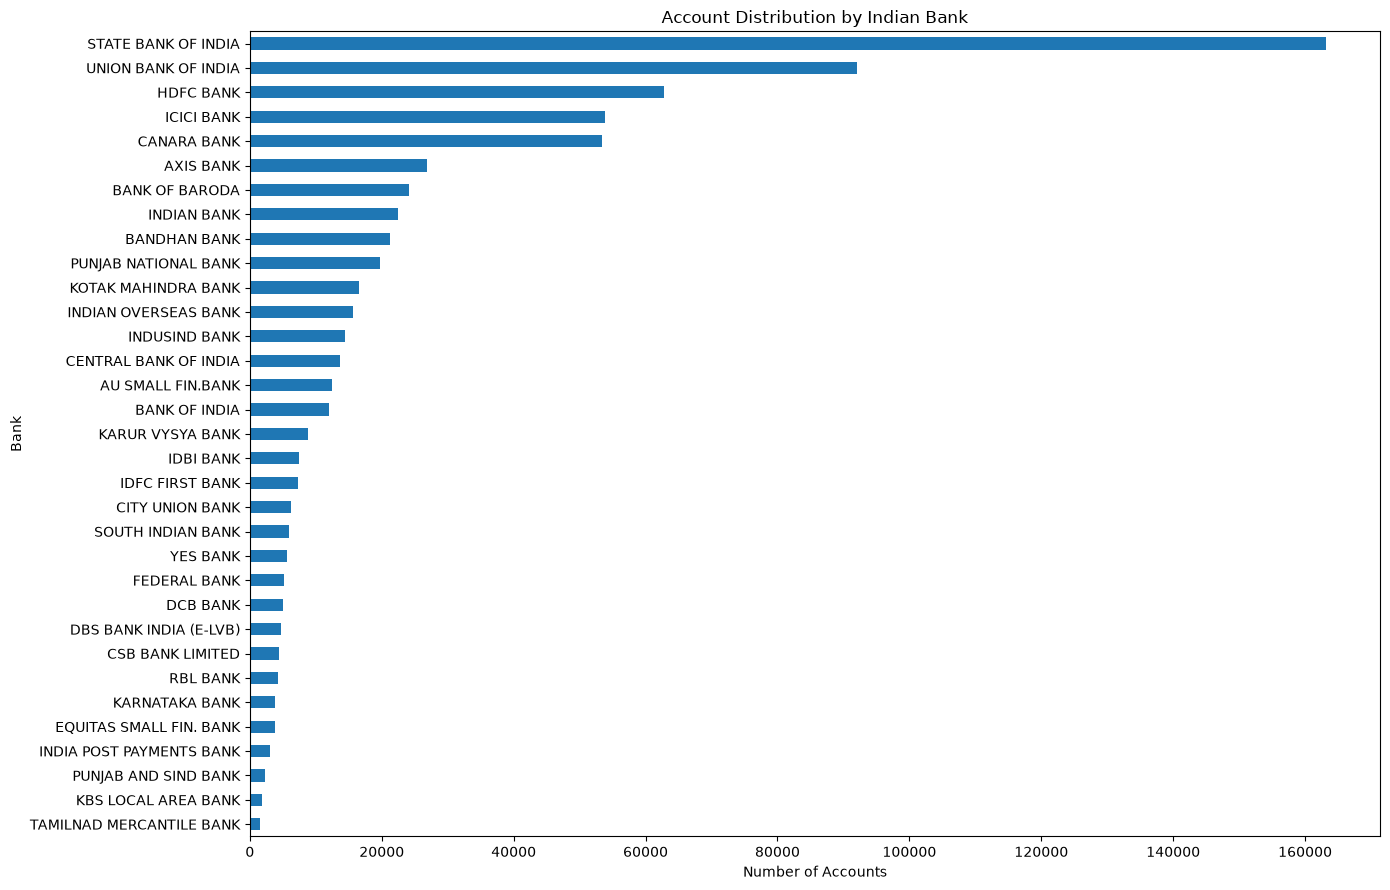

,accounts,branch_weight,target_share,total_transactions,laundering_transactions,actual_share,share_error,laundering_rate
Indian Bank,,,,,,,,
STATE BANK OF INDIA,163193,1215.0,0.231870,3110012.0,1535.0,0.231182,-0.000688,0.000494
UNION BANK OF INDIA,92009,683.0,0.130344,1901344.0,1038.0,0.130342,-0.000002,0.000546
HDFC BANK,62777,465.0,0.088740,1178025.0,626.0,0.088931,0.000191,0.000531
ICICI BANK,53781,398.0,0.075954,997894.0,445.0,0.076187,0.000233,0.000446
CANARA BANK,53386,396.0,0.075573,1250594.0,870.0,0.075628,0.000055,0.000696
AXIS BANK,26903,199.0,0.037977,509200.0,260.0,0.038111,0.000134,0.000511
BANK OF BARODA,24074,178.0,0.033969,452031.0,205.0,0.034104,0.000134,0.000454
INDIAN BANK,22487,167.0,0.031870,421557.0,184.0,0.031855,-0.000015,0.000436
BANDHAN BANK,21242,159.0,0.030344,398192.0,154.0,0.030092,-0.000252,0.000387


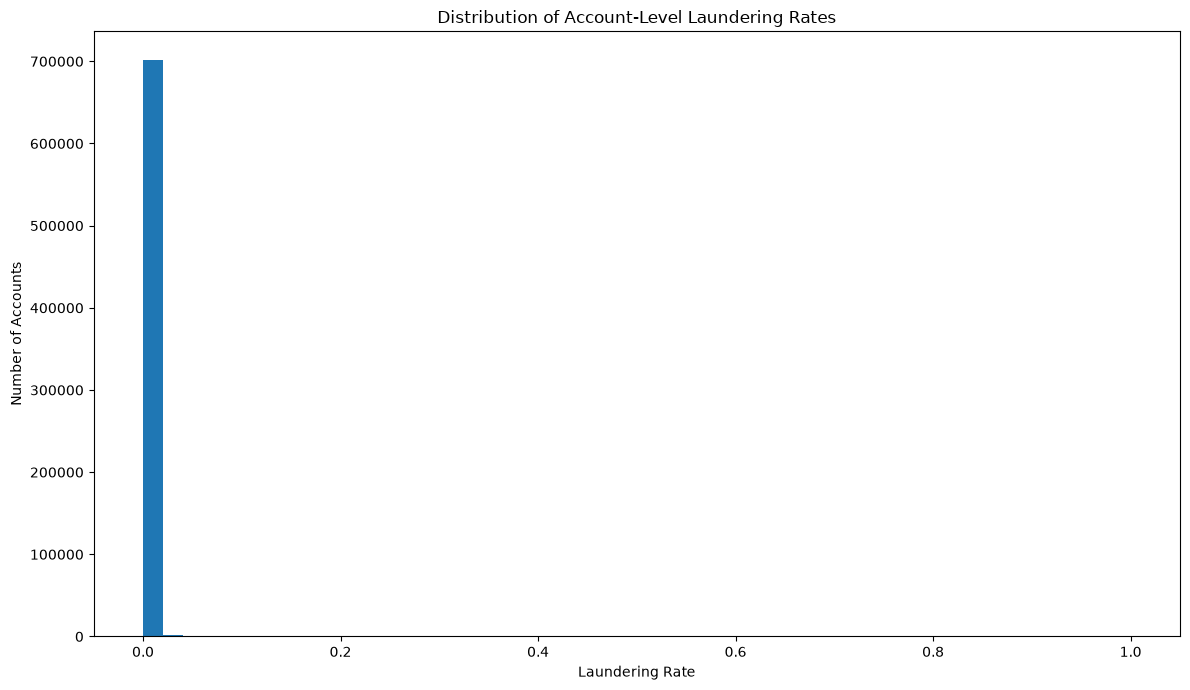


Top accounts by laundering transactions:


,Account Number,District,Indian Bank,total_transactions,laundering_transactions,laundering_rate,total_amount
229793,10042B660,Mahabubnagar,CANARA BANK,223590.0,314.0,0.001404,7.311454e+10
229893,10042B6A8,Rachakonda Commissionerate,UNION BANK OF INDIA,139728.0,196.0,0.001403,3.745186e+10
230011,10042B6F0,Railway Police Secunderabad,CITY UNION BANK,42730.0,48.0,0.001123,1.059057e+11
231053,10042BA08,Khammam Commissionerate,IDFC FIRST BANK,22587.0,39.0,0.001727,2.331919e+10
229483,10042B780,Nirmal,AU SMALL FIN.BANK,31025.0,32.0,0.001031,7.291879e+11
231167,10042BA51,Hyderabad Commissionerate,CANARA BANK,29016.0,31.0,0.001068,7.629145e+05
231674,10042B9C0,Nirmal,INDUSIND BANK,16362.0,29.0,0.001772,2.743786e+10
229376,10042B738,Medak,UNION BANK OF INDIA,18348.0,28.0,0.001526,9.243020e+11
231883,10042B858,Khammam Commissionerate,UNION BANK OF INDIA,15814.0,27.0,0.001707,6.038979e+09
231979,10042B8A0,Hyderabad Commissionerate,STATE BANK OF INDIA,19414.0,25.0,0.001288,9.356313e+09



Top accounts by laundering rate:


,Account Number,District,Indian Bank,total_transactions,laundering_transactions,laundering_rate,total_amount
693697,8016B3750,Cyberabad Commissionerate,PUNJAB NATIONAL BANK,10.0,8.0,0.800000,86335.49
4539,807F00750,Jagityal,HDFC BANK,8.0,6.0,0.750000,5889158.86
247214,8105AC9A0,Rachakonda Commissionerate,IDFC FIRST BANK,14.0,9.0,0.642857,172702.56
332859,8026B9C00,Adilabad,HDFC BANK,5.0,3.0,0.600000,19835.77
450145,80055C8A0,Warangal Commissionerate,UNION BANK OF INDIA,14.0,8.0,0.571429,162491.77
168223,8005366A0,Mahabubabad,UNION BANK OF INDIA,8.0,4.0,0.500000,37314.17
155040,80011B960,Kamareddy,UNION BANK OF INDIA,39.0,19.0,0.487179,331819.03
80967,800851CF0,Jogulamba Gadwal,STATE BANK OF INDIA,7.0,3.0,0.428571,2135210.64
19334,800283000,Ramagundam Commissionerate,KOTAK MAHINDRA BANK,5.0,2.0,0.400000,16130.62
14344,801E9E0F0,Jagityal,INDIAN OVERSEAS BANK,5.0,2.0,0.400000,52197.89



DISTRICT CALIBRATION QUALITY


,population_share,actual_account_share,population_error,crime_share,actual_laundering_share,crime_error
District,,,,,,
Cyberabad Commissionerate,0.066430,0.066429,-1.359976e-07,0.354579,0.111080,-0.243499
Hyderabad Commissionerate,0.107083,0.107085,1.992011e-06,0.289992,0.113464,-0.176527
Rachakonda Commissionerate,0.066430,0.066431,1.280620e-06,0.143296,0.099860,-0.043436
Warangal Commissionerate,0.048592,0.048591,-5.418900e-07,0.041250,0.042917,0.001667
Kamareddy,0.026412,0.026411,-7.139294e-07,0.019285,0.035764,0.016480
Sangareddy,0.041484,0.041483,-7.113959e-07,0.018696,0.032679,0.013982
Siddipet Commissionerate,0.027483,0.027482,-7.645227e-07,0.016082,0.024544,0.008463
Khammam Commissionerate,0.038062,0.038062,-5.467612e-07,0.015493,0.039832,0.024338
Jagityal,0.026759,0.026760,4.006562e-07,0.010198,0.027349,0.017151



Mean absolute population-share error: 0.0000%
Mean absolute crime-share error: 3.0898%

District × Indian Bank account matrix:


Indian Bank,AU SMALL FIN.BANK,AXIS BANK,BANDHAN BANK,BANK OF BARODA,BANK OF INDIA,CANARA BANK,CENTRAL BANK OF INDIA,CITY UNION BANK,CSB BANK LIMITED,DBS BANK INDIA (E-LVB),...,KBS LOCAL AREA BANK,KOTAK MAHINDRA BANK,PUNJAB AND SIND BANK,PUNJAB NATIONAL BANK,RBL BANK,SOUTH INDIAN BANK,STATE BANK OF INDIA,TAMILNAD MERCANTILE BANK,UNION BANK OF INDIA,YES BANK
District,,,,,,,,,,,,,,,,,,,,,
Adilabad,240,523,357,464,243,1014,259,127,88,78,...,37,313,37,383,89,151,3127,24,1764,118
Bhadradri Kothagudem,380,739,578,675,344,1571,381,187,134,131,...,64,467,76,550,167,191,4688,47,2637,174
Cyberabad Commissionerate,835,1775,1415,1597,819,3532,863,422,299,284,...,108,1070,155,1305,276,386,10861,123,6096,357
Hyderabad Commissionerate,1346,2934,2231,2631,1247,5665,1498,665,509,526,...,186,1764,282,2124,465,652,17515,167,9773,638
Jagityal,312,700,592,647,317,1383,349,154,113,146,...,48,416,70,522,107,150,4380,33,2512,158
Jayashankar Bhupalpalli,132,277,256,292,130,594,174,72,48,49,...,20,195,25,226,50,62,1869,12,952,56
Jogulamba Gadwal,219,442,350,399,190,866,240,120,61,75,...,25,278,31,292,82,112,2726,24,1538,103
Kamareddy,332,694,560,633,317,1461,370,163,118,125,...,48,441,53,543,112,146,4314,48,2410,136
Karimnagar Commissionerate,334,778,617,650,314,1450,367,162,101,129,...,55,445,63,565,122,160,4426,32,2487,178



SUMMARY
Total accounts: 712688
Accounts with laundering activity: 5304
Total transactions represented: 13848205.0
Total laundering transactions: 7130.0
Overall account-level laundering rate: 0.0515%
Districts: 30
Indian banks: 33


In [15]:
# ============================================================
# ENRICHED ACCOUNTS — COMPLETE ANALYSIS
# ============================================================

accounts_df = pd.read_csv("enriched_accounts.csv")

print("=" * 70)
print("ENRICHED ACCOUNTS DATASET")
print("=" * 70)

print("\nDataset shape:", accounts_df.shape)

print("\nColumns:")
print(accounts_df.columns.tolist())

print("\nPreview:")
display(accounts_df.head())


# ============================================================
# BASIC STATISTICS
# ============================================================

print("\nBasic statistics:")
display(accounts_df.describe(include="all").T)


# ============================================================
# MISSING VALUES
# ============================================================

print("\nMissing values:")
display(
    accounts_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing")
)


# ============================================================
# DISTRICT — ACCOUNT DISTRIBUTION
# ============================================================

district_accounts = (
    accounts_df["District"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 9))
district_accounts.sort_values().plot(kind="barh")
plt.title("Account Distribution by District")
plt.xlabel("Number of Accounts")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ============================================================
# DISTRICT — POPULATION SHARE VS ACTUAL ACCOUNT SHARE
# ============================================================

district_distribution = (
    accounts_df
    .groupby("District")
    .agg(
        accounts=("Account Number", "count"),
        population=("Population", "first"),
        crime_count=("Crime Count", "first"),
        population_share=("Population Share", "first"),
        crime_share=("Crime Share", "first"),
        total_transactions=("total_transactions", "sum"),
        laundering_transactions=(
            "laundering_transactions",
            "sum"
        )
    )
)

district_distribution["actual_account_share"] = (
    district_distribution["accounts"]
    / district_distribution["accounts"].sum()
)

district_distribution["laundering_rate"] = (
    district_distribution["laundering_transactions"]
    / district_distribution["total_transactions"]
)

district_distribution["account_share_error"] = (
    district_distribution["actual_account_share"]
    - district_distribution["population_share"]
)

display(
    district_distribution.sort_values(
        "accounts",
        ascending=False
    )
)


# ============================================================
# POPULATION SHARE COMPARISON
# ============================================================

comparison = district_distribution[
    [
        "population_share",
        "actual_account_share"
    ]
].sort_values(
    "population_share",
    ascending=False
)

comparison.plot(
    kind="bar",
    figsize=(16, 9)
)

plt.title(
    "Target Population Share vs Actual Account Distribution"
)

plt.xlabel("District")
plt.ylabel("Share")

plt.xticks(rotation=75)
plt.legend(
    [
        "Population Share",
        "Actual Account Share"
    ]
)

plt.tight_layout()
plt.show()


# ============================================================
# ACCOUNT LAUNDERING DISTRIBUTION
# ============================================================

district_laundering_accounts = (
    accounts_df
    .groupby("District")
    .agg(
        accounts=("Account Number", "count"),
        laundering_accounts=(
            "laundering_transactions",
            lambda x: (x > 0).sum()
        ),
        laundering_transactions=(
            "laundering_transactions",
            "sum"
        ),
        total_transactions=(
            "total_transactions",
            "sum"
        )
    )
)

district_laundering_accounts["accounts_with_laundering_rate"] = (
    district_laundering_accounts["laundering_accounts"]
    / district_laundering_accounts["accounts"]
)

district_laundering_accounts["transaction_laundering_rate"] = (
    district_laundering_accounts["laundering_transactions"]
    / district_laundering_accounts["total_transactions"]
)

display(
    district_laundering_accounts
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
)


# ============================================================
# BANK — ACCOUNT DISTRIBUTION
# ============================================================

bank_accounts = (
    accounts_df["Indian Bank"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 9))
bank_accounts.sort_values().plot(kind="barh")
plt.title("Account Distribution by Indian Bank")
plt.xlabel("Number of Accounts")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ============================================================
# BANK — TARGET SHARE VS ACTUAL SHARE
# ============================================================

bank_distribution = (
    accounts_df
    .groupby("Indian Bank")
    .agg(
        accounts=("Account Number", "count"),
        branch_weight=("Branch Weight", "first"),
        target_share=("Bank Share", "first"),
        total_transactions=("total_transactions", "sum"),
        laundering_transactions=(
            "laundering_transactions",
            "sum"
        )
    )
)

bank_distribution["actual_share"] = (
    bank_distribution["accounts"]
    / bank_distribution["accounts"].sum()
)

bank_distribution["share_error"] = (
    bank_distribution["actual_share"]
    - bank_distribution["target_share"]
)

bank_distribution["laundering_rate"] = (
    bank_distribution["laundering_transactions"]
    / bank_distribution["total_transactions"]
)

display(
    bank_distribution.sort_values(
        "accounts",
        ascending=False
    )
)


# ============================================================
# ACCOUNT LAUNDERING RATE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

accounts_df["laundering_rate"].plot(
    kind="hist",
    bins=50
)

plt.title("Distribution of Account-Level Laundering Rates")
plt.xlabel("Laundering Rate")
plt.ylabel("Number of Accounts")
plt.tight_layout()
plt.show()


# ============================================================
# TOP ACCOUNTS BY LAUNDERING ACTIVITY
# ============================================================

print("\nTop accounts by laundering transactions:")

top_laundering_accounts = (
    accounts_df[
        [
            "Account Number",
            "District",
            "Indian Bank",
            "total_transactions",
            "laundering_transactions",
            "laundering_rate",
            "total_amount"
        ]
    ]
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
    .head(25)
)

display(top_laundering_accounts)


# ============================================================
# TOP ACCOUNTS BY LAUNDERING RATE
# ============================================================

print("\nTop accounts by laundering rate:")

top_rate_accounts = (
    accounts_df[
        [
            "Account Number",
            "District",
            "Indian Bank",
            "total_transactions",
            "laundering_transactions",
            "laundering_rate",
            "total_amount"
        ]
    ]
    .query("total_transactions >= 5")
    .sort_values(
        "laundering_rate",
        ascending=False
    )
    .head(25)
)

display(top_rate_accounts)


# ============================================================
# CRIME / POPULATION CALIBRATION
# ============================================================

calibration = (
    accounts_df
    .groupby("District")
    .agg(
        accounts=("Account Number", "count"),
        population=("Population", "first"),
        crime_count=("Crime Count", "first"),
        population_share=("Population Share", "first"),
        crime_share=("Crime Share", "first"),
        actual_laundering=(
            "laundering_transactions",
            "sum"
        )
    )
)

calibration["actual_account_share"] = (
    calibration["accounts"]
    / calibration["accounts"].sum()
)

calibration["actual_laundering_share"] = (
    calibration["actual_laundering"]
    / calibration["actual_laundering"].sum()
)

calibration["population_error"] = (
    calibration["actual_account_share"]
    - calibration["population_share"]
)

calibration["crime_error"] = (
    calibration["actual_laundering_share"]
    - calibration["crime_share"]
)

print("\nDISTRICT CALIBRATION QUALITY")

display(
    calibration[
        [
            "population_share",
            "actual_account_share",
            "population_error",
            "crime_share",
            "actual_laundering_share",
            "crime_error"
        ]
    ]
    .sort_values(
        "crime_share",
        ascending=False
    )
)


print(
    "\nMean absolute population-share error:",
    f"{calibration['population_error'].abs().mean():.4%}"
)

print(
    "Mean absolute crime-share error:",
    f"{calibration['crime_error'].abs().mean():.4%}"
)


# ============================================================
# DISTRICT × BANK MATRIX
# ============================================================

district_bank_matrix = pd.crosstab(
    accounts_df["District"],
    accounts_df["Indian Bank"]
)

print("\nDistrict × Indian Bank account matrix:")
display(district_bank_matrix)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print("Total accounts:", len(accounts_df))
print(
    "Accounts with laundering activity:",
    (accounts_df["laundering_transactions"] > 0).sum()
)

print(
    "Total transactions represented:",
    accounts_df["total_transactions"].sum()
)

print(
    "Total laundering transactions:",
    accounts_df["laundering_transactions"].sum()
)

print(
    "Overall account-level laundering rate:",
    f"{accounts_df['laundering_transactions'].sum() / accounts_df['total_transactions'].sum():.4%}"
)

print(
    "Districts:",
    accounts_df["District"].nunique()
)

print(
    "Indian banks:",
    accounts_df["Indian Bank"].nunique()
)

In [16]:
# Find transaction rows containing at least one missing value
missing_rows = df2[df2.isna().any(axis=1)].copy()

print(f"Rows with missing data: {len(missing_rows):,}")

# Accounts involved in rows with missing data
account_columns = ["from_account", "to_account"]

accounts_with_missing_rows = pd.unique(
    missing_rows[account_columns].values.ravel()
)
accounts_with_missing_rows = sorted(
    account for account in accounts_with_missing_rows
    if pd.notna(account)
)

print(f"Accounts involved: {len(accounts_with_missing_rows):,}")

# Missing-column summary for each account
account_missing_summary = []

for account in accounts_with_missing_rows:
    account_rows = missing_rows[
        (missing_rows["from_account"] == account) |
        (missing_rows["to_account"] == account)
    ]

    missing_columns = (
        account_rows.isna()
        .sum()
        .loc[lambda x: x > 0]
        .to_dict()
    )

    account_missing_summary.append({
        "account": account,
        "rows_with_missing_data": len(account_rows),
        "missing_columns": missing_columns
    })

account_missing_summary = pd.DataFrame(account_missing_summary)

display(
    account_missing_summary.sort_values(
        "rows_with_missing_data",
        ascending=False
    )
)

# Display all affected transaction rows
display(
    missing_rows.sort_values(
        ["from_account", "to_account"]
    )
)

Rows with missing data: 5,417
Accounts involved: 5,304


,account,rows_with_missing_data,missing_columns
0,10042B660,314,"{'synthetic_source_tx1': 314, 'synthetic_sourc..."
1,10042B6A8,196,"{'synthetic_source_tx1': 196, 'synthetic_sourc..."
2,10042B6F0,48,"{'synthetic_source_tx1': 48, 'synthetic_source..."
13,10042BA08,39,"{'synthetic_source_tx1': 39, 'synthetic_source..."
4,10042B780,32,"{'synthetic_source_tx1': 32, 'synthetic_source..."
...,...,...,...
5288,81C0CAC30,1,"{'synthetic_source_tx1': 1, 'synthetic_source_..."
21,800067220,1,"{'synthetic_source_tx1': 1, 'synthetic_source_..."
18,8000597D0,1,"{'synthetic_source_tx1': 1, 'synthetic_source_..."
17,80004B460,1,"{'synthetic_source_tx1': 1, 'synthetic_source_..."


,timestamp,from_account,to_account,amount_paid,payment_mode,is_laundering,from_district,to_district,from_indian_bank,to_indian_bank,...,second_stage_generation,target_account_original_frequency,target_account_profile_frequency,target_district_distance_km,target_selection_score,synthetic_delay_minutes,payment_format,amount_received,day,hour
4271,2022-09-09 01:27:00,10042B660,80022C4D0,27268.90,UPI,True,Mahabubnagar,Railway Police Secunderabad,CANARA BANK,INDIAN BANK,...,NaN,NaN,NaN,NaN,NaN,NaN,UPI,27268.90,9,1
2673,2022-09-06 09:23:00,10042B660,80084A340,667.24,UPI,True,Mahabubnagar,Sangareddy,CANARA BANK,CANARA BANK,...,NaN,NaN,NaN,NaN,NaN,NaN,UPI,667.24,6,9
2698,2022-09-06 10:22:00,10042B660,800855290,8245.90,ATM WITHDRAWAL,True,Mahabubnagar,Railway Police Secunderabad,CANARA BANK,STATE BANK OF INDIA,...,NaN,NaN,NaN,NaN,NaN,NaN,ATM WITHDRAWAL,8245.90,6,10
4234,2022-09-08 23:35:00,10042B660,8008C9770,199.85,UPI,True,Mahabubnagar,Cyberabad Commissionerate,CANARA BANK,CANARA BANK,...,NaN,NaN,NaN,NaN,NaN,NaN,UPI,199.85,8,23
4506,2022-09-09 11:11:00,10042B660,8008D5CA0,1143.27,UPI,True,Mahabubnagar,Railway Police Secunderabad,CANARA BANK,STATE BANK OF INDIA,...,NaN,NaN,NaN,NaN,NaN,NaN,UPI,1143.27,9,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687,2022-09-04 13:31:00,81C1EC380,8001582E0,16086.77,IMPS,True,Warangal Commissionerate,Railway Police Secunderabad,STATE BANK OF INDIA,INDIAN OVERSEAS BANK,...,NaN,NaN,NaN,NaN,NaN,NaN,IMPS,16086.77,4,13
1814,2022-09-04 17:55:00,81C1EC380,800DC5470,6083.52,IMPS,True,Warangal Commissionerate,Rachakonda Commissionerate,STATE BANK OF INDIA,STATE BANK OF INDIA,...,NaN,NaN,NaN,NaN,NaN,NaN,IMPS,6083.52,4,17
1517,2022-09-04 04:36:00,81C1EC380,80124A7F0,9664.69,IMPS,True,Warangal Commissionerate,Jogulamba Gadwal,STATE BANK OF INDIA,STATE BANK OF INDIA,...,NaN,NaN,NaN,NaN,NaN,NaN,IMPS,9664.69,4,4
1300,2022-09-03 16:10:00,81C1EC380,801A51990,5051.72,IMPS,True,Warangal Commissionerate,Hyderabad Commissionerate,STATE BANK OF INDIA,ICICI BANK,...,NaN,NaN,NaN,NaN,NaN,NaN,IMPS,5051.72,3,16


In [17]:
# ============================================================
# FILL MISSING DISTRICT + INDIAN BANK IN enriched_accounts.csv
# USING TRANSACTION DATA (df2)
# ============================================================

import pandas as pd
import numpy as np

# Load enriched accounts
accounts_df = pd.read_csv("enriched_accounts.csv")
df2 = pd.read_csv("enriched_transactions.csv")

df2.columns = [
    "timestamp",
    "from_indian_bank",
    "from_account",
    "to_indian_bank",
    "to_account",
    "amount_received",
    "receiving_currency",
    "amount_paid",
    "payment_currency",
    "payment_format",
    "is_laundering",

    # NEW COLUMNS
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank"
]

# ------------------------------------------------------------
# 1. Build account -> district/bank mappings from df2
# ------------------------------------------------------------

# Sender account mapping
from_map = df2[
    ["from_account", "from_district", "from_indian_bank"]
].rename(columns={
    "from_account": "Account Number",
    "from_district": "District",
    "from_indian_bank": "Indian Bank"
})

# Receiver account mapping
to_map = df2[
    ["to_account", "to_district", "to_indian_bank"]
].rename(columns={
    "to_account": "Account Number",
    "to_district": "District",
    "to_indian_bank": "Indian Bank"
})

# Combine both sides
account_tx_map = pd.concat(
    [from_map, to_map],
    ignore_index=True
)

# Remove rows where account number is missing
account_tx_map = account_tx_map.dropna(
    subset=["Account Number"]
)

# ------------------------------------------------------------
# 2. Check whether an account has conflicting mappings
# ------------------------------------------------------------

district_conflicts = (
    account_tx_map
    .dropna(subset=["District"])
    .groupby("Account Number")["District"]
    .nunique()
)

bank_conflicts = (
    account_tx_map
    .dropna(subset=["Indian Bank"])
    .groupby("Account Number")["Indian Bank"]
    .nunique()
)

print("Accounts with conflicting district mappings:",
      (district_conflicts > 1).sum())

print("Accounts with conflicting bank mappings:",
      (bank_conflicts > 1).sum())


# ------------------------------------------------------------
# 3. Resolve mappings
#
# If an account appears multiple times, use the most frequent
# district/bank associated with that account.
# ------------------------------------------------------------

district_map = (
    account_tx_map
    .dropna(subset=["District"])
    .groupby("Account Number")["District"]
    .agg(lambda x: x.mode().iloc[0])
)

bank_map = (
    account_tx_map
    .dropna(subset=["Indian Bank"])
    .groupby("Account Number")["Indian Bank"]
    .agg(lambda x: x.mode().iloc[0])
)


# ------------------------------------------------------------
# 4. Fill ONLY missing values in accounts_df
# ------------------------------------------------------------

# Keep original values untouched
missing_district = (
    accounts_df["District"].isna() |
    accounts_df["District"].astype(str).str.strip().isin(["", "nan"])
)

missing_bank = (
    accounts_df["Indian Bank"].isna() |
    accounts_df["Indian Bank"].astype(str).str.strip().isin(["", "nan"])
)

# Map transaction-derived values
district_from_tx = accounts_df["Account Number"].map(district_map)
bank_from_tx = accounts_df["Account Number"].map(bank_map)

# Fill only missing values
accounts_df.loc[missing_district, "District"] = (
    district_from_tx[missing_district]
)

accounts_df.loc[missing_bank, "Indian Bank"] = (
    bank_from_tx[missing_bank]
)


# ------------------------------------------------------------
# 5. Report results
# ------------------------------------------------------------

print("\n========== FILL RESULTS ==========")

print("Rows in accounts:", len(accounts_df))

print(
    "District values filled:",
    missing_district.sum() - accounts_df.loc[missing_district, "District"].isna().sum()
)

print(
    "Indian Bank values filled:",
    missing_bank.sum() - accounts_df.loc[missing_bank, "Indian Bank"].isna().sum()
)

print(
    "District still missing:",
    accounts_df["District"].isna().sum()
)

print(
    "Indian Bank still missing:",
    accounts_df["Indian Bank"].isna().sum()
)


# ------------------------------------------------------------
# 6. Save corrected file
# ------------------------------------------------------------

accounts_df.to_csv(
    "enriched_accounts.csv",
    index=False
)

print("\nSaved corrected file:")
print("enriched_accounts.csv")


# ------------------------------------------------------------
# 7. Show remaining problematic rows
# ------------------------------------------------------------

remaining = accounts_df[
    accounts_df["District"].isna() |
    accounts_df["Indian Bank"].isna()
]

print("\nRemaining rows without district/bank:", len(remaining))

if len(remaining) > 0:
    display(
        remaining[
            [
                "Account Number",
                "Bank Name",
                "Entity Name",
                "District",
                "Indian Bank"
            ]
        ].head(20)
    )

Accounts with conflicting district mappings: 0
Accounts with conflicting bank mappings: Indian Bank    4
Indian Bank    0
dtype: int64


KeyboardInterrupt: 

In [ ]:
# ============================================================
# REMOVE ACCOUNTS THAT NEVER APPEAR IN TRANSACTIONS
# ============================================================

# Get all account numbers that appear in transactions
transaction_accounts = set(
    pd.concat([
        df2["from_account"],
        df2["to_account"]
    ])
    .dropna()
    .astype(str)
    .str.strip()
)

# Normalize account numbers in accounts_df
accounts_df["Account Number"] = (
    accounts_df["Account Number"]
    .astype(str)
    .str.strip()
)

# Keep only accounts that appear in at least one transaction
new_accounts = accounts_df[
    accounts_df["Account Number"].isin(transaction_accounts)
].copy()

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Original accounts:", len(accounts_df))
print("Accounts removed:", len(accounts_df) - len(new_accounts))
print("New accounts:", len(new_accounts))

print(
    "Missing District after filtering:",
    new_accounts["District"].isna().sum()
)

print(
    "Missing Indian Bank after filtering:",
    new_accounts["Indian Bank"].isna().sum()
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

new_accounts.to_csv(
    "new_accounts.csv",
    index=False
)

print("\nSaved: new_accounts.csv")

In [ ]:
# ============================================================
# COMPLETE PAYMENT-MODE BEHAVIOR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. OVERALL SUMMARY BY PAYMENT MODE
# ------------------------------------------------------------

mode_summary = (
    df2.groupby("payment_format")
    .agg(
        transactions=("payment_format", "size"),
        total_amount=("amount_paid", "sum"),
        avg_amount=("amount_paid", "mean"),
        median_amount=("amount_paid", "median"),
        min_amount=("amount_paid", "min"),
        max_amount=("amount_paid", "max"),
        std_amount=("amount_paid", "std"),
        laundering_transactions=("is_laundering", "sum"),
        laundering_rate=("is_laundering", "mean"),
        unique_from_accounts=("from_account", "nunique"),
        unique_to_accounts=("to_account", "nunique")
    )
    .sort_values("transactions", ascending=False)
)

mode_summary["transaction_share"] = (
    mode_summary["transactions"] /
    mode_summary["transactions"].sum() * 100
)

mode_summary["laundering_rate"] *= 100

print("========== PAYMENT MODE SUMMARY ==========")
display(mode_summary.round(2))


# ------------------------------------------------------------
# 2. TRANSACTION AMOUNT QUANTILES
# ------------------------------------------------------------

amount_stats = (
    df2.groupby("payment_format")["amount_paid"]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .unstack()
)

amount_stats.columns = [
    "P01", "P05", "P25", "P50", "P75", "P95", "P99"
]

print("\n========== TRANSACTION AMOUNT QUANTILES ==========")
display(amount_stats.round(2))


# ------------------------------------------------------------
# 3. BOXPLOT OF TRANSACTION AMOUNTS
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

df2.boxplot(
    column="amount_paid",
    by="payment_format",
    grid=False,
    showfliers=False
)

plt.title("Transaction Amount Distribution by Payment Mode")
plt.suptitle("")
plt.xlabel("Payment Mode")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. LOG-SCALE TRANSACTION AMOUNT DISTRIBUTION
# ------------------------------------------------------------

plot_df = df2[
    df2["amount_paid"].notna() &
    (df2["amount_paid"] > 0)
].copy()

plt.figure(figsize=(12, 6))

for mode in plot_df["payment_format"].dropna().unique():

    values = plot_df.loc[
        plot_df["payment_format"] == mode,
        "amount_paid"
    ]

    plt.hist(
        np.log10(values),
        bins=50,
        alpha=0.45,
        label=mode
    )

plt.title("Log-Scale Transaction Amount Distribution")
plt.xlabel("log10(Transaction Amount)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. TEMPORAL BEHAVIOR
# ------------------------------------------------------------

temporal_df = df2.copy()

temporal_df["hour"] = temporal_df["timestamp"].dt.hour
temporal_df["day_of_week"] = temporal_df["timestamp"].dt.day_name()

temporal_summary = (
    temporal_df
    .groupby("payment_format")
    .agg(
        avg_hour=("hour", "mean"),
        median_hour=("hour", "median"),
        most_common_hour=("hour", lambda x: x.mode().iloc[0]),
        most_common_day=("day_of_week", lambda x: x.mode().iloc[0])
    )
)

print("\n========== TEMPORAL BEHAVIOR ==========")
display(temporal_summary.round(2))


# ------------------------------------------------------------
# 6. LAUNDERING VS NORMAL TRANSACTIONS
# ------------------------------------------------------------

laundering_summary = (
    df2
    .groupby(["payment_format", "is_laundering"])
    .agg(
        transactions=("payment_format", "size"),
        total_amount=("amount_paid", "sum"),
        avg_amount=("amount_paid", "mean"),
        median_amount=("amount_paid", "median")
    )
    .reset_index()
)

print("\n========== LAUNDERING VS NORMAL ==========")
display(
    laundering_summary
    .sort_values(["payment_format", "is_laundering"])
    .round(2)
)


# ------------------------------------------------------------
# 7. ACCOUNT CONCENTRATION
# ------------------------------------------------------------

account_concentration = (
    df2
    .groupby("payment_format")
    .agg(
        unique_sender_accounts=("from_account", "nunique"),
        unique_receiver_accounts=("to_account", "nunique"),
        transactions=("payment_format", "size")
    )
)

account_concentration["transactions_per_sender"] = (
    account_concentration["transactions"] /
    account_concentration["unique_sender_accounts"]
)

account_concentration["transactions_per_receiver"] = (
    account_concentration["transactions"] /
    account_concentration["unique_receiver_accounts"]
)

print("\n========== ACCOUNT CONCENTRATION ==========")
display(account_concentration.round(2))


# ------------------------------------------------------------
# 8. DISTRICT BEHAVIOR
# ------------------------------------------------------------

district_behavior = (
    df2
    .groupby("payment_format")
    .agg(
        unique_from_districts=("from_district", "nunique"),
        unique_to_districts=("to_district", "nunique"),
        top_from_district=(
            "from_district",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        ),
        top_to_district=(
            "to_district",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
)

print("\n========== DISTRICT BEHAVIOR ==========")
display(district_behavior)


# ------------------------------------------------------------
# 9. BANK BEHAVIOR
# ------------------------------------------------------------

bank_behavior = (
    df2
    .groupby("payment_format")
    .agg(
        unique_from_indian_banks=("from_indian_bank", "nunique"),
        unique_to_indian_banks=("to_indian_bank", "nunique"),
        top_from_indian_bank=(
            "from_indian_bank",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        ),
        top_to_indian_bank=(
            "to_indian_bank",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
)

print("\n========== BANK BEHAVIOR ==========")
display(bank_behavior)


# ------------------------------------------------------------
# 10. TOP 10 TRANSACTIONS WITHIN EACH PAYMENT MODE
# ------------------------------------------------------------

top_transactions = (
    df2
    .sort_values("amount_paid", ascending=False)
    .groupby("payment_format")
    .head(10)
    [
        [
            "timestamp",
            "payment_format",
            "from_account",
            "to_account",
            "amount_paid",
            "is_laundering",
            "from_district",
            "to_district",
            "from_indian_bank",
            "to_indian_bank"
        ]
    ]
)

print("\n========== TOP TRANSACTIONS BY PAYMENT MODE ==========")
display(top_transactions)


# ------------------------------------------------------------
# 11. TRANSACTION SHARE
# ------------------------------------------------------------

transaction_share = (
    df2["payment_format"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .to_frame()
)

print("\n========== TRANSACTION SHARE ==========")
display(transaction_share)


# ------------------------------------------------------------
# 12. FINAL COMBINED TABLE
# ------------------------------------------------------------

final_comparison = mode_summary[
    [
        "transactions",
        "transaction_share",
        "total_amount",
        "avg_amount",
        "median_amount",
        "min_amount",
        "max_amount",
        "laundering_transactions",
        "laundering_rate",
        "unique_from_accounts",
        "unique_to_accounts"
    ]
].copy()

print("\n========== FINAL PAYMENT-MODE COMPARISON ==========")
display(final_comparison.round(2))

In [ ]:
# ============================================================
# CREATE NEW INDIAN-CONTEXT TRANSACTION DATASET
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. LOAD ENRICHED TRANSACTIONS
# ------------------------------------------------------------

df = pd.read_csv("enriched_transactions.csv")

print("Original shape:", df.shape)
print("\nOriginal columns:")
print(df.columns.tolist())

df.columns = [
    "timestamp",
    "from_indian_bank",
    "from_account",
    "to_indian_bank",
    "to_account",
    "amount_received",
    "receiving_currency",
    "amount_paid",
    "payment_currency",
    "payment_format",
    "is_laundering",

    # NEW COLUMNS
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank"
]

# ------------------------------------------------------------
# 2. MAP IBM PAYMENT MODES TO INDIAN-CONTEXT MODES
# ------------------------------------------------------------

PAYMENT_MODE_MAP = {
    "Cheque": "UPI",
    "Credit Card": "UPI",
    "Reinvestment": "UPI",
    
    "ACH": "IMPS",
    "Wire": "NEFT",
    
    "Cash": "ATM Withdrawal",
    
    "Bitcoin": "Other Digital"
}

df["payment_mode"] = df["payment_format"].map(PAYMENT_MODE_MAP)


# ------------------------------------------------------------
# 3. CHECK FOR UNMAPPED PAYMENT MODES
# ------------------------------------------------------------

unmapped = df.loc[
    df["payment_mode"].isna(),
    "payment_format"
].dropna().unique()

if len(unmapped) > 0:
    print("\nWARNING: Unmapped payment modes:")
    print(unmapped)
else:
    print("\nAll payment modes successfully mapped.")


# ------------------------------------------------------------
# 4. KEEP ONLY REQUIRED COLUMNS
# ------------------------------------------------------------
#
# We keep:
#
# timestamp          -> temporal modelling
# from_account       -> transaction graph
# to_account         -> transaction graph
# amount_paid        -> financial behaviour
# payment_mode       -> Indian-context transaction channel
# is_laundering      -> suspicious/laundering label
# from_district      -> origin geography
# to_district        -> destination geography
# from_indian_bank   -> Indian banking context
# to_indian_bank     -> Indian banking context
#
# We remove:
#
# from_indian_bank / to_indian_bank       -> IBM/US banking identifiers
# receiving_currency        -> unnecessary for INR-focused dataset
# payment_currency          -> unnecessary for INR-focused dataset
# amount_received           -> duplicate financial value for our use
# payment_format            -> replaced by payment_mode
#

required_columns = [
    "timestamp",
    "from_account",
    "to_account",
    "amount_paid",
    "payment_mode",
    "is_laundering",
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank"
]

new_transactions = df[required_columns].copy()


# ------------------------------------------------------------
# 5. CLEAN DATA TYPES
# ------------------------------------------------------------

new_transactions["timestamp"] = pd.to_datetime(
    new_transactions["timestamp"],
    errors="coerce"
)

new_transactions["amount_paid"] = pd.to_numeric(
    new_transactions["amount_paid"],
    errors="coerce"
)

new_transactions["from_account"] = (
    new_transactions["from_account"]
    .astype(str)
    .str.strip()
)

new_transactions["to_account"] = (
    new_transactions["to_account"]
    .astype(str)
    .str.strip()
)

for col in [
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank"
]:
    new_transactions[col] = (
        new_transactions[col]
        .astype(str)
        .str.strip()
        .replace("nan", np.nan)
    )


# ------------------------------------------------------------
# 6. REMOVE INVALID ROWS
# ------------------------------------------------------------

before = len(new_transactions)

new_transactions = new_transactions.dropna(
    subset=[
        "timestamp",
        "from_account",
        "to_account",
        "amount_paid",
        "payment_mode"
    ]
)

new_transactions = new_transactions[
    new_transactions["amount_paid"] >= 0
]

after = len(new_transactions)

print("\nRows removed during cleaning:", before - after)


# ------------------------------------------------------------
# 7. REORDER COLUMNS
# ------------------------------------------------------------

new_transactions = new_transactions[
    [
        "timestamp",
        "from_account",
        "to_account",
        "amount_paid",
        "payment_mode",
        "is_laundering",
        "from_district",
        "to_district",
        "from_indian_bank",
        "to_indian_bank"
    ]
]


# ------------------------------------------------------------
# 8. SAVE
# ------------------------------------------------------------

new_transactions.to_csv(
    "new_transactions.csv",
    index=False
)


# ------------------------------------------------------------
# 9. VALIDATION
# ------------------------------------------------------------

print("\n================================================")
print("NEW TRANSACTION DATASET")
print("================================================")

print("Shape:", new_transactions.shape)

print("\nColumns:")
print(new_transactions.columns.tolist())

print("\nPayment-mode distribution:")
mode_distribution = (
    new_transactions["payment_mode"]
    .value_counts()
    .to_frame("transactions")
)

mode_distribution["percentage"] = (
    mode_distribution["transactions"]
    / len(new_transactions)
    * 100
)

display(mode_distribution.round(2))

print("\nSample:")
display(new_transactions.head())

print("\nMissing values:")
display(new_transactions.isna().sum())

print("\nSaved as:")
print("new_transactions.csv")

In [ ]:
# ============================================================
# COMPLETE PAYMENT-MODE BEHAVIOR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. OVERALL SUMMARY BY PAYMENT MODE
# ------------------------------------------------------------
df2 = pd.read_csv("new_transactions.csv")
df2["payment_format"] = df2["payment_mode"]
df2["timestamp"] = pd.to_datetime(
    df2["timestamp"],
    # format="%Y/%m/%d %H:%M:%S",
    errors="coerce"
)
mode_summary = (
    df2.groupby("payment_format")
    .agg(
        transactions=("payment_format", "size"),
        total_amount=("amount_paid", "sum"),
        avg_amount=("amount_paid", "mean"),
        median_amount=("amount_paid", "median"),
        min_amount=("amount_paid", "min"),
        max_amount=("amount_paid", "max"),
        std_amount=("amount_paid", "std"),
        laundering_transactions=("is_laundering", "sum"),
        laundering_rate=("is_laundering", "mean"),
        unique_from_accounts=("from_account", "nunique"),
        unique_to_accounts=("to_account", "nunique")
    )
    .sort_values("transactions", ascending=False)
)

mode_summary["transaction_share"] = (
    mode_summary["transactions"] /
    mode_summary["transactions"].sum() * 100
)

mode_summary["laundering_rate"] *= 100

print("========== PAYMENT MODE SUMMARY ==========")
display(mode_summary.round(2))


# ------------------------------------------------------------
# 2. TRANSACTION AMOUNT QUANTILES
# ------------------------------------------------------------

amount_stats = (
    df2.groupby("payment_format")["amount_paid"]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .unstack()
)

amount_stats.columns = [
    "P01", "P05", "P25", "P50", "P75", "P95", "P99"
]

print("\n========== TRANSACTION AMOUNT QUANTILES ==========")
display(amount_stats.round(2))


# ------------------------------------------------------------
# 3. BOXPLOT OF TRANSACTION AMOUNTS
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

df2.boxplot(
    column="amount_paid",
    by="payment_format",
    grid=False,
    showfliers=False
)

plt.title("Transaction Amount Distribution by Payment Mode")
plt.suptitle("")
plt.xlabel("Payment Mode")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. LOG-SCALE TRANSACTION AMOUNT DISTRIBUTION
# ------------------------------------------------------------

plot_df = df2[
    df2["amount_paid"].notna() &
    (df2["amount_paid"] > 0)
].copy()

plt.figure(figsize=(12, 6))

for mode in plot_df["payment_format"].dropna().unique():

    values = plot_df.loc[
        plot_df["payment_format"] == mode,
        "amount_paid"
    ]

    plt.hist(
        np.log10(values),
        bins=50,
        alpha=0.45,
        label=mode
    )

plt.title("Log-Scale Transaction Amount Distribution")
plt.xlabel("log10(Transaction Amount)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. TEMPORAL BEHAVIOR
# ------------------------------------------------------------

temporal_df = df2.copy()

temporal_df["hour"] = temporal_df["timestamp"].dt.hour
temporal_df["day_of_week"] = temporal_df["timestamp"].dt.day_name()

temporal_summary = (
    temporal_df
    .groupby("payment_format")
    .agg(
        avg_hour=("hour", "mean"),
        median_hour=("hour", "median"),
        most_common_hour=("hour", lambda x: x.mode().iloc[0]),
        most_common_day=("day_of_week", lambda x: x.mode().iloc[0])
    )
)

print("\n========== TEMPORAL BEHAVIOR ==========")
display(temporal_summary.round(2))


# ------------------------------------------------------------
# 6. LAUNDERING VS NORMAL TRANSACTIONS
# ------------------------------------------------------------

laundering_summary = (
    df2
    .groupby(["payment_format", "is_laundering"])
    .agg(
        transactions=("payment_format", "size"),
        total_amount=("amount_paid", "sum"),
        avg_amount=("amount_paid", "mean"),
        median_amount=("amount_paid", "median")
    )
    .reset_index()
)

print("\n========== LAUNDERING VS NORMAL ==========")
display(
    laundering_summary
    .sort_values(["payment_format", "is_laundering"])
    .round(2)
)


# ------------------------------------------------------------
# 7. ACCOUNT CONCENTRATION
# ------------------------------------------------------------

account_concentration = (
    df2
    .groupby("payment_format")
    .agg(
        unique_sender_accounts=("from_account", "nunique"),
        unique_receiver_accounts=("to_account", "nunique"),
        transactions=("payment_format", "size")
    )
)

account_concentration["transactions_per_sender"] = (
    account_concentration["transactions"] /
    account_concentration["unique_sender_accounts"]
)

account_concentration["transactions_per_receiver"] = (
    account_concentration["transactions"] /
    account_concentration["unique_receiver_accounts"]
)

print("\n========== ACCOUNT CONCENTRATION ==========")
display(account_concentration.round(2))


# ------------------------------------------------------------
# 8. DISTRICT BEHAVIOR
# ------------------------------------------------------------

district_behavior = (
    df2
    .groupby("payment_format")
    .agg(
        unique_from_districts=("from_district", "nunique"),
        unique_to_districts=("to_district", "nunique"),
        top_from_district=(
            "from_district",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        ),
        top_to_district=(
            "to_district",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
)

print("\n========== DISTRICT BEHAVIOR ==========")
display(district_behavior)


# ------------------------------------------------------------
# 9. BANK BEHAVIOR
# ------------------------------------------------------------

bank_behavior = (
    df2
    .groupby("payment_format")
    .agg(
        unique_from_indian_banks=("from_indian_bank", "nunique"),
        unique_to_indian_banks=("to_indian_bank", "nunique"),
        top_from_indian_bank=(
            "from_indian_bank",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        ),
        top_to_indian_bank=(
            "to_indian_bank",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
)

print("\n========== BANK BEHAVIOR ==========")
display(bank_behavior)


# ------------------------------------------------------------
# 10. TOP 10 TRANSACTIONS WITHIN EACH PAYMENT MODE
# ------------------------------------------------------------

top_transactions = (
    df2
    .sort_values("amount_paid", ascending=False)
    .groupby("payment_format")
    .head(10)
    [
        [
            "timestamp",
            "payment_format",
            "from_account",
            "to_account",
            "amount_paid",
            "is_laundering",
            "from_district",
            "to_district",
            "from_indian_bank",
            "to_indian_bank"
        ]
    ]
)

print("\n========== TOP TRANSACTIONS BY PAYMENT MODE ==========")
display(top_transactions)


# ------------------------------------------------------------
# 11. TRANSACTION SHARE
# ------------------------------------------------------------

transaction_share = (
    df2["payment_format"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .to_frame()
)

print("\n========== TRANSACTION SHARE ==========")
display(transaction_share)


# ------------------------------------------------------------
# 12. FINAL COMBINED TABLE
# ------------------------------------------------------------

final_comparison = mode_summary[
    [
        "transactions",
        "transaction_share",
        "total_amount",
        "avg_amount",
        "median_amount",
        "min_amount",
        "max_amount",
        "laundering_transactions",
        "laundering_rate",
        "unique_from_accounts",
        "unique_to_accounts"
    ]
].copy()

print("\n========== FINAL PAYMENT-MODE COMPARISON ==========")
display(final_comparison.round(2))

In [ ]:
# ============================================================
# TRANSACTION-LEVEL DISTRICT & BANK ANALYSIS
# Uses existing df2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. DISTRICT DISTRIBUTION — TRANSACTION COUNT
# ------------------------------------------------------------

from_district_counts = (
    df2["from_district"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
from_district_counts.sort_values().plot(kind="barh")
plt.title("Transaction Distribution by From District")
plt.xlabel("Number of Transactions")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. DISTRICT DISTRIBUTION — LAUNDERING TRANSACTIONS
# ------------------------------------------------------------

district_laundering = (
    df2[df2["is_laundering"]]
    ["from_district"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
district_laundering.sort_values().plot(kind="barh")
plt.title("Laundering Transactions by From District")
plt.xlabel("Number of Laundering Transactions")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. DISTRICT — TOTAL AMOUNT
# ------------------------------------------------------------

district_amount = (
    df2.groupby("from_district")["amount_paid"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
district_amount.sort_values().plot(kind="barh")
plt.title("Transaction Amount by From District")
plt.xlabel("Total Amount")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. DISTRICT — LAUNDERING RATE
# ------------------------------------------------------------

district_stats = (
    df2.groupby("from_district")
    .agg(
        transactions=("from_district", "size"),
        laundering_transactions=("is_laundering", "sum"),
        total_amount=("amount_paid", "sum"),
        laundering_amount=(
            "amount_paid",
            lambda x: x[df2.loc[x.index, "is_laundering"]].sum()
        )
    )
)

district_stats["laundering_rate"] = (
    district_stats["laundering_transactions"]
    / district_stats["transactions"]
)

district_stats = district_stats.sort_values(
    "laundering_rate",
    ascending=False
)

plt.figure(figsize=(14, 8))
district_stats["laundering_rate"].sort_values().plot(
    kind="barh"
)
plt.title("Laundering Rate by District")
plt.xlabel("Laundering Rate")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. BANK DISTRIBUTION — TRANSACTION COUNT
# ------------------------------------------------------------

bank_counts = (
    df2["from_indian_bank"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
bank_counts.sort_values().plot(kind="barh")
plt.title("Transaction Distribution by Indian Bank")
plt.xlabel("Number of Transactions")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. BANK — LAUNDERING TRANSACTIONS
# ------------------------------------------------------------

bank_laundering = (
    df2[df2["is_laundering"]]
    ["from_indian_bank"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
bank_laundering.sort_values().plot(kind="barh")
plt.title("Laundering Transactions by Indian Bank")
plt.xlabel("Number of Laundering Transactions")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. BANK — LAUNDERING RATE
# ------------------------------------------------------------

bank_stats = (
    df2.groupby("from_indian_bank")
    .agg(
        transactions=("from_indian_bank", "size"),
        laundering_transactions=("is_laundering", "sum"),
        total_amount=("amount_paid", "sum")
    )
)

bank_stats["laundering_rate"] = (
    bank_stats["laundering_transactions"]
    / bank_stats["transactions"]
)

bank_stats = bank_stats.sort_values(
    "laundering_rate",
    ascending=False
)

plt.figure(figsize=(14, 8))
bank_stats["laundering_rate"].sort_values().plot(
    kind="barh"
)
plt.title("Laundering Rate by Indian Bank")
plt.xlabel("Laundering Rate")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. PAYMENT FORMAT × DISTRICT
# ------------------------------------------------------------

district_payment = pd.crosstab(
    df2["from_district"],
    df2["payment_format"]
)

plt.figure(figsize=(16, 10))
district_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 10)
)
plt.title("Transaction Types Across Districts")
plt.xlabel("District")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=75)
plt.legend(title="Payment Format", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. PAYMENT FORMAT × BANK
# ------------------------------------------------------------

bank_payment = pd.crosstab(
    df2["from_indian_bank"],
    df2["payment_format"]
)

bank_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 9)
)

plt.title("Transaction Types Across Indian Banks")
plt.xlabel("Bank")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=75)
plt.legend(
    title="Payment Format",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. DISTRICT × LAUNDERING STATUS
# ------------------------------------------------------------

district_laundering_table = pd.crosstab(
    df2["from_district"],
    df2["is_laundering"]
)

district_laundering_table = district_laundering_table.rename(
    columns={
        False: "Legitimate",
        True: "Laundering"
    }
)

display(
    district_laundering_table
    .sort_values("Laundering", ascending=False)
)


# ------------------------------------------------------------
# 11. BANK × LAUNDERING STATUS
# ------------------------------------------------------------

bank_laundering_table = pd.crosstab(
    df2["from_indian_bank"],
    df2["is_laundering"]
)

bank_laundering_table = bank_laundering_table.rename(
    columns={
        False: "Legitimate",
        True: "Laundering"
    }
)

display(
    bank_laundering_table
    .sort_values("Laundering", ascending=False)
)


# ------------------------------------------------------------
# 12. DISTRICT → DISTRICT TRANSACTION FLOW
# ------------------------------------------------------------

district_flow = pd.crosstab(
    df2["from_district"],
    df2["to_district"]
)

print("District-to-district transaction matrix:")
display(district_flow)


# ------------------------------------------------------------
# 13. TOP DISTRICT FLOWS
# ------------------------------------------------------------

top_district_flows = (
    df2.groupby(
        ["from_district", "to_district"]
    )
    .size()
    .reset_index(name="transactions")
    .sort_values(
        "transactions",
        ascending=False
    )
    .head(25)
)

print("Top 25 district-to-district flows:")
display(top_district_flows)


# ------------------------------------------------------------
# 14. TOP BANK FLOWS
# ------------------------------------------------------------

top_bank_flows = (
    df2.groupby(
        ["from_indian_bank", "to_indian_bank"]
    )
    .size()
    .reset_index(name="transactions")
    .sort_values(
        "transactions",
        ascending=False
    )
    .head(25)
)

print("Top 25 bank-to-bank flows:")
display(top_bank_flows)


# ------------------------------------------------------------
# 15. SUMMARY TABLE — DISTRICTS
# ------------------------------------------------------------

print("\nDISTRICT SUMMARY")

district_summary = (
    df2.groupby("from_district")
    .agg(
        transactions=("from_district", "size"),
        total_amount=("amount_paid", "sum"),
        laundering_transactions=("is_laundering", "sum"),
        unique_accounts=("from_account", "nunique"),
        unique_banks=("from_indian_bank", "nunique")
    )
)

district_summary["laundering_rate"] = (
    district_summary["laundering_transactions"]
    / district_summary["transactions"]
)

display(
    district_summary
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
)


# ------------------------------------------------------------
# 16. SUMMARY TABLE — BANKS
# ------------------------------------------------------------

print("\nBANK SUMMARY")

bank_summary = (
    df2.groupby("from_indian_bank")
    .agg(
        transactions=("from_indian_bank", "size"),
        total_amount=("amount_paid", "sum"),
        laundering_transactions=("is_laundering", "sum"),
        unique_accounts=("from_account", "nunique"),
        unique_districts=("from_district", "nunique")
    )
)

bank_summary["laundering_rate"] = (
    bank_summary["laundering_transactions"]
    / bank_summary["transactions"]
)

display(
    bank_summary
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
)

In [ ]:
# ============================================================
# CREATE CLEAN ACCOUNT DATASET
# Source: new_accounts.csv
# Output: new_accounts_2.csv
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. LOAD
# ------------------------------------------------------------

accounts = pd.read_csv("new_accounts.csv")

print("Original shape:", accounts.shape)

print("\nOriginal columns:")
print(accounts.columns.tolist())


# ------------------------------------------------------------
# 2. KEEP ONLY REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "Account Number",
    "Entity Name",
    "District",
    "Indian Bank",
    "total_transactions",
    "total_amount",
    "laundering_transactions",
    "laundering_rate",
    "Population",
    "Crime Count",
    "Crime_Population_Index"
]

missing_columns = [
    col for col in required_columns
    if col not in accounts.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

new_accounts_2 = accounts[required_columns].copy()


# ------------------------------------------------------------
# 3. CLEAN DATA TYPES
# ------------------------------------------------------------

new_accounts_2["Account Number"] = (
    new_accounts_2["Account Number"]
    .astype(str)
    .str.strip()
)

new_accounts_2["Entity Name"] = (
    new_accounts_2["Entity Name"]
    .astype(str)
    .str.strip()
)

new_accounts_2["District"] = (
    new_accounts_2["District"]
    .astype(str)
    .str.strip()
    .replace("nan", np.nan)
)

new_accounts_2["Indian Bank"] = (
    new_accounts_2["Indian Bank"]
    .astype(str)
    .str.strip()
    .replace("nan", np.nan)
)


numeric_columns = [
    "total_transactions",
    "total_amount",
    "laundering_transactions",
    "laundering_rate",
    "Population",
    "Crime Count",
    "Crime_Population_Index"
]

for col in numeric_columns:
    new_accounts_2[col] = pd.to_numeric(
        new_accounts_2[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# 4. BASIC VALIDATION
# ------------------------------------------------------------

print("\nMissing values:")
print(new_accounts_2.isna().sum())

print("\nDuplicate Account Numbers:")
print(
    new_accounts_2["Account Number"].duplicated().sum()
)


# ------------------------------------------------------------
# 5. REMOVE INVALID ACCOUNTS
# ------------------------------------------------------------

before = len(new_accounts_2)

new_accounts_2 = new_accounts_2.dropna(
    subset=[
        "Account Number",
        "District",
        "Indian Bank"
    ]
)

after = len(new_accounts_2)

print("\nInvalid/incomplete rows removed:", before - after)


# ------------------------------------------------------------
# 6. SAVE
# ------------------------------------------------------------

new_accounts_2.to_csv(
    "new_accounts_2.csv",
    index=False
)


# ------------------------------------------------------------
# 7. FINAL VALIDATION
# ------------------------------------------------------------

print("\n================================================")
print("NEW ACCOUNT DATASET")
print("================================================")

print("Shape:", new_accounts_2.shape)

print("\nColumns:")
for col in new_accounts_2.columns:
    print(" -", col)

print("\nDistricts:", new_accounts_2["District"].nunique())

print("Indian Banks:", new_accounts_2["Indian Bank"].nunique())

print(
    "Unique Accounts:",
    new_accounts_2["Account Number"].nunique()
)

print("\nSample:")
display(new_accounts_2.head())

print("\nSaved as:")
print("new_accounts_2.csv")